# Near-Duplicate Detection: Experimental Analysis

This notebook summarises the generated outputs for the MinHash and LSH near-duplicate detection project. The main experiments use fixed 5,000-document samples from 20 Newsgroups and Reuters-21578. The notebook reads the saved result tables and figures. It does not replace or rerun the experiment scripts.

The full pipeline is:

```text
documents -> word shingles -> MinHash signatures -> LSH candidates
```


In [3]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

TABLES = ROOT / "results" / "tables"
FIGURES = ROOT / "results" / "figures"

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

## Main experiment results

The main experiments use 5,000 documents from 20 Newsgroups and Reuters-21578.

For each dataset, the code tests:

- shingle sizes `k = 3, 5, 7`
- three MinHash families
- 50, 100 and 200 hash values
- several LSH banding configurations

In [4]:
newsgroups = pd.read_csv(TABLES / "final_20_newsgroups_results.csv")
reuters = pd.read_csv(TABLES / "final_reuters_results.csv")

results = pd.concat([newsgroups, reuters], ignore_index=True)

columns = [
    "dataset",
    "k",
    "hash_family",
    "num_hashes",
    "num_bands",
    "rows_per_band",
    "ground_truth_pairs",
    "lsh_candidate_pairs",
    "true_positives",
    "false_positives",
    "false_negatives",
    "precision",
    "recall",
    "f1_score",
]

best = (
    results.loc[results.groupby("dataset")["f1_score"].idxmax(), columns]
    .reset_index(drop=True)
    .round(
        {
            "precision": 3,
            "recall": 3,
            "f1_score": 3,
        }
    )
)

best

,dataset,k,hash_family,num_hashes,num_bands,rows_per_band,ground_truth_pairs,lsh_candidate_pairs,true_positives,false_positives,false_negatives,precision,recall,f1_score
0,20_newsgroups,5,linear,50,25,2,156,215,147,68,9,0.684,0.942,0.792
1,reuters,7,linear,200,50,4,186,147,142,5,44,0.966,0.763,0.853


The best observed 20 Newsgroups configuration uses k = 5, the linear hash family, 50 hash values and 25 bands of two rows. It finds 147 of the 156 positive pairs and reaches an F1-score of 0.792.

The best Reuters-21578 configuration uses k = 7, the linear hash family, 200 hash values and 50 bands of four rows. It finds 142 of the 186 positive pairs and reaches an F1-score of 0.853.

The different results show that the best parameter settings depend on the dataset.

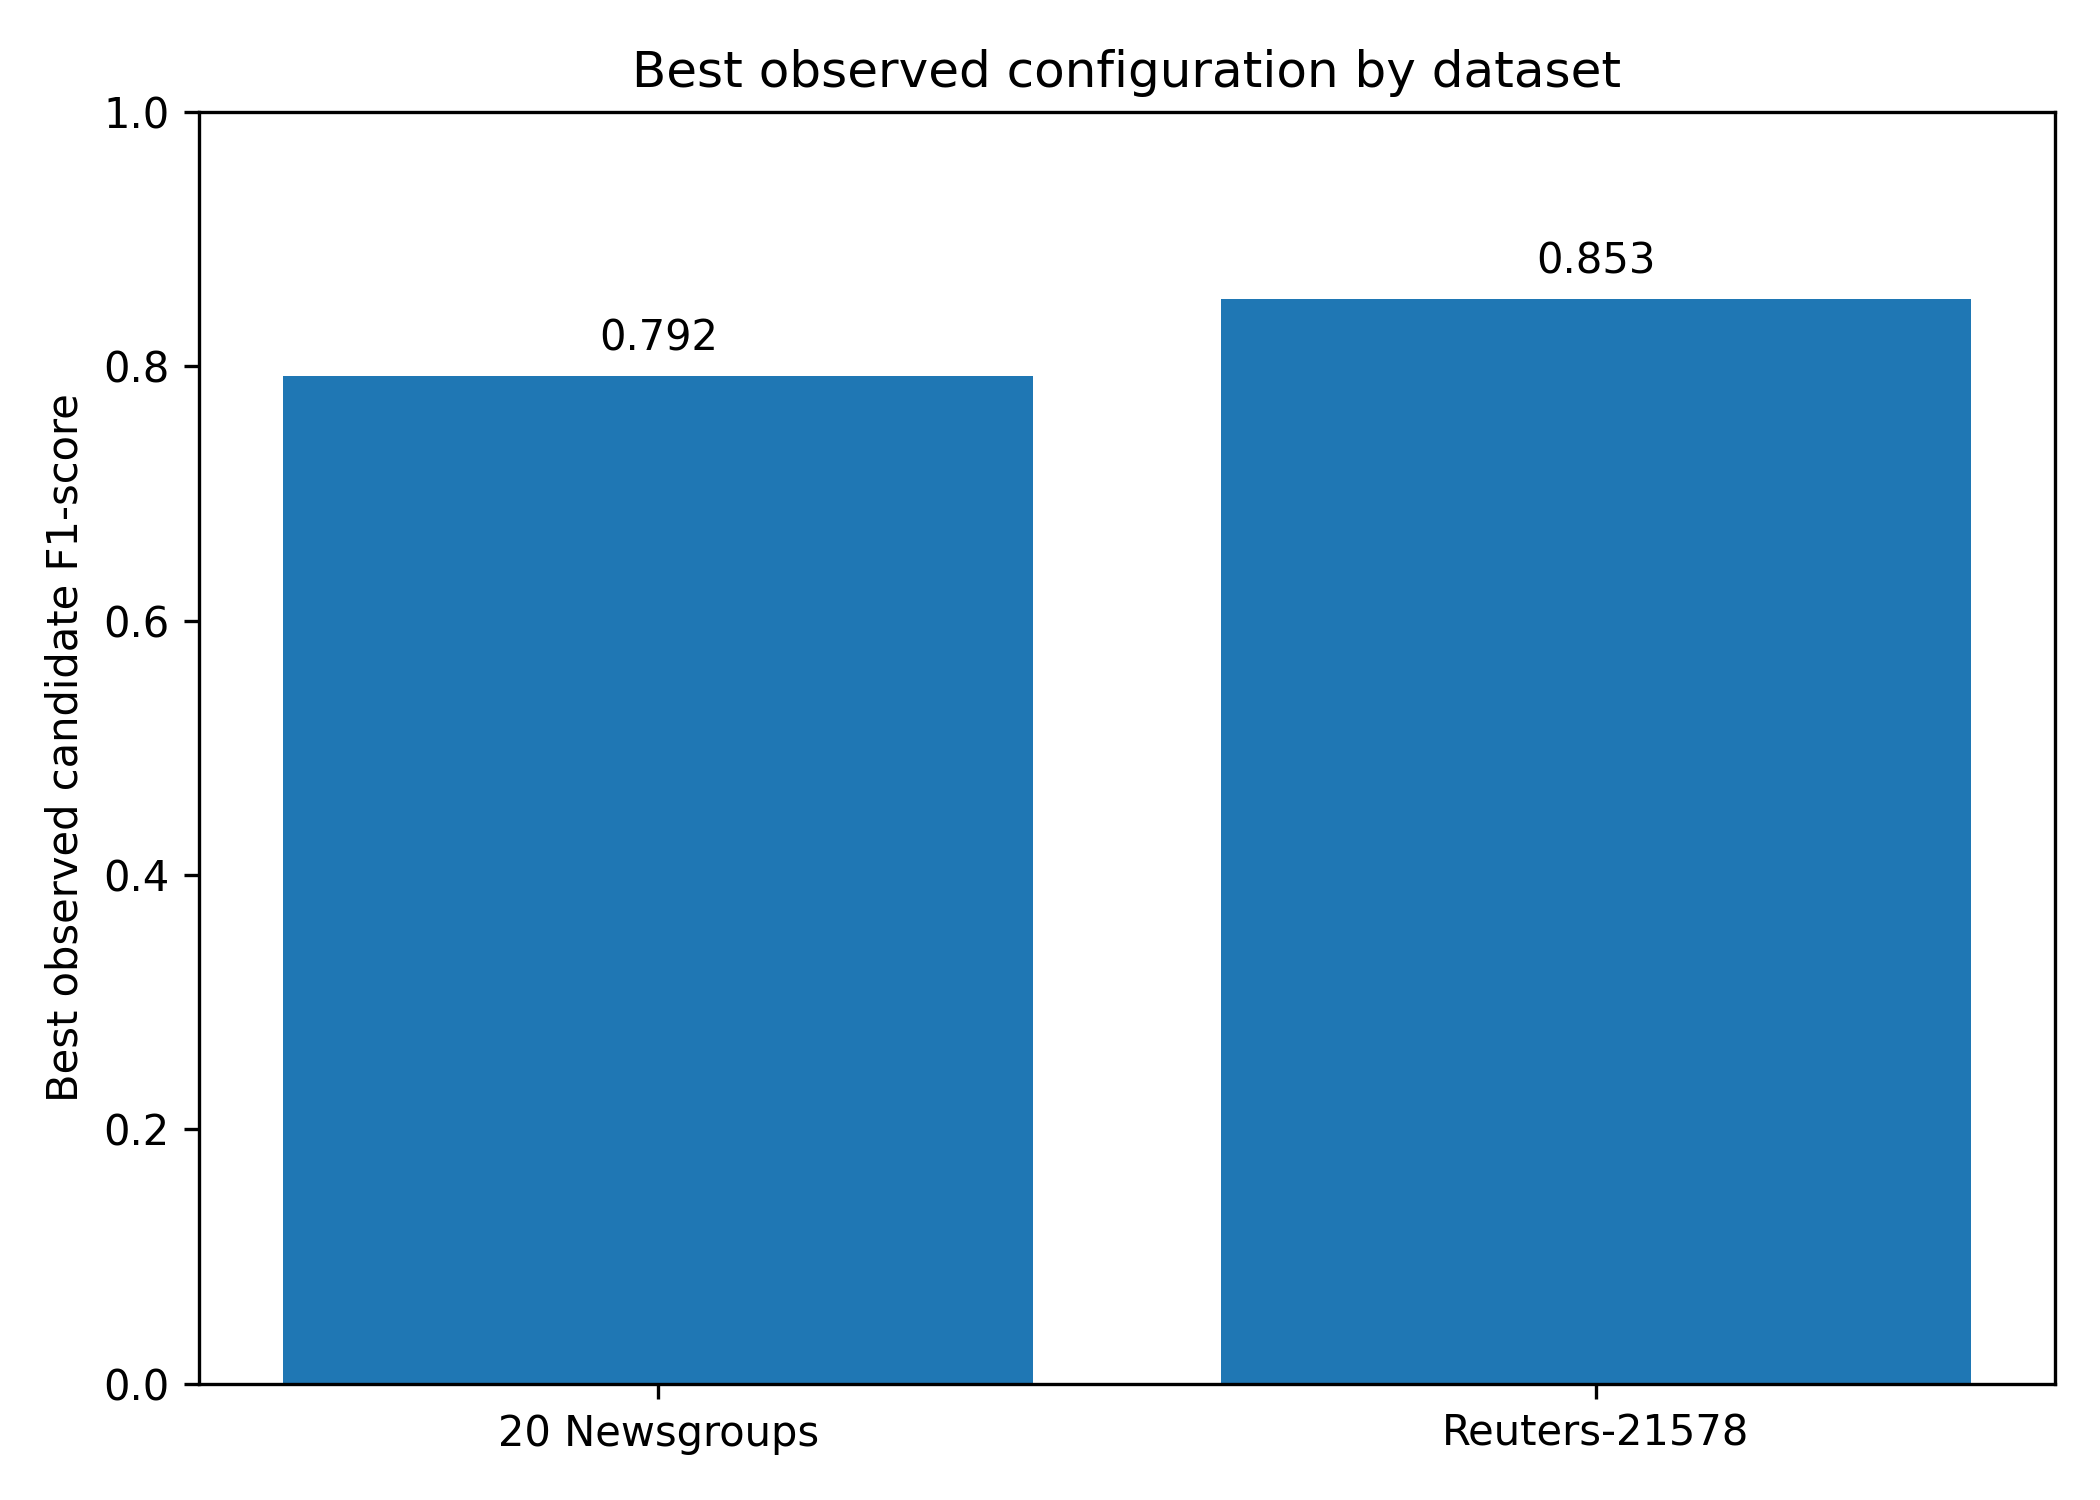

In [19]:
display(
    Image(
        filename=str(
            FIGURES / "final_comparison" / "best_f1_by_dataset.png"
        ),
        width=500
    )
)

Reuters-21578 reaches the higher best F1-score, although the two datasets use different parameter settings.

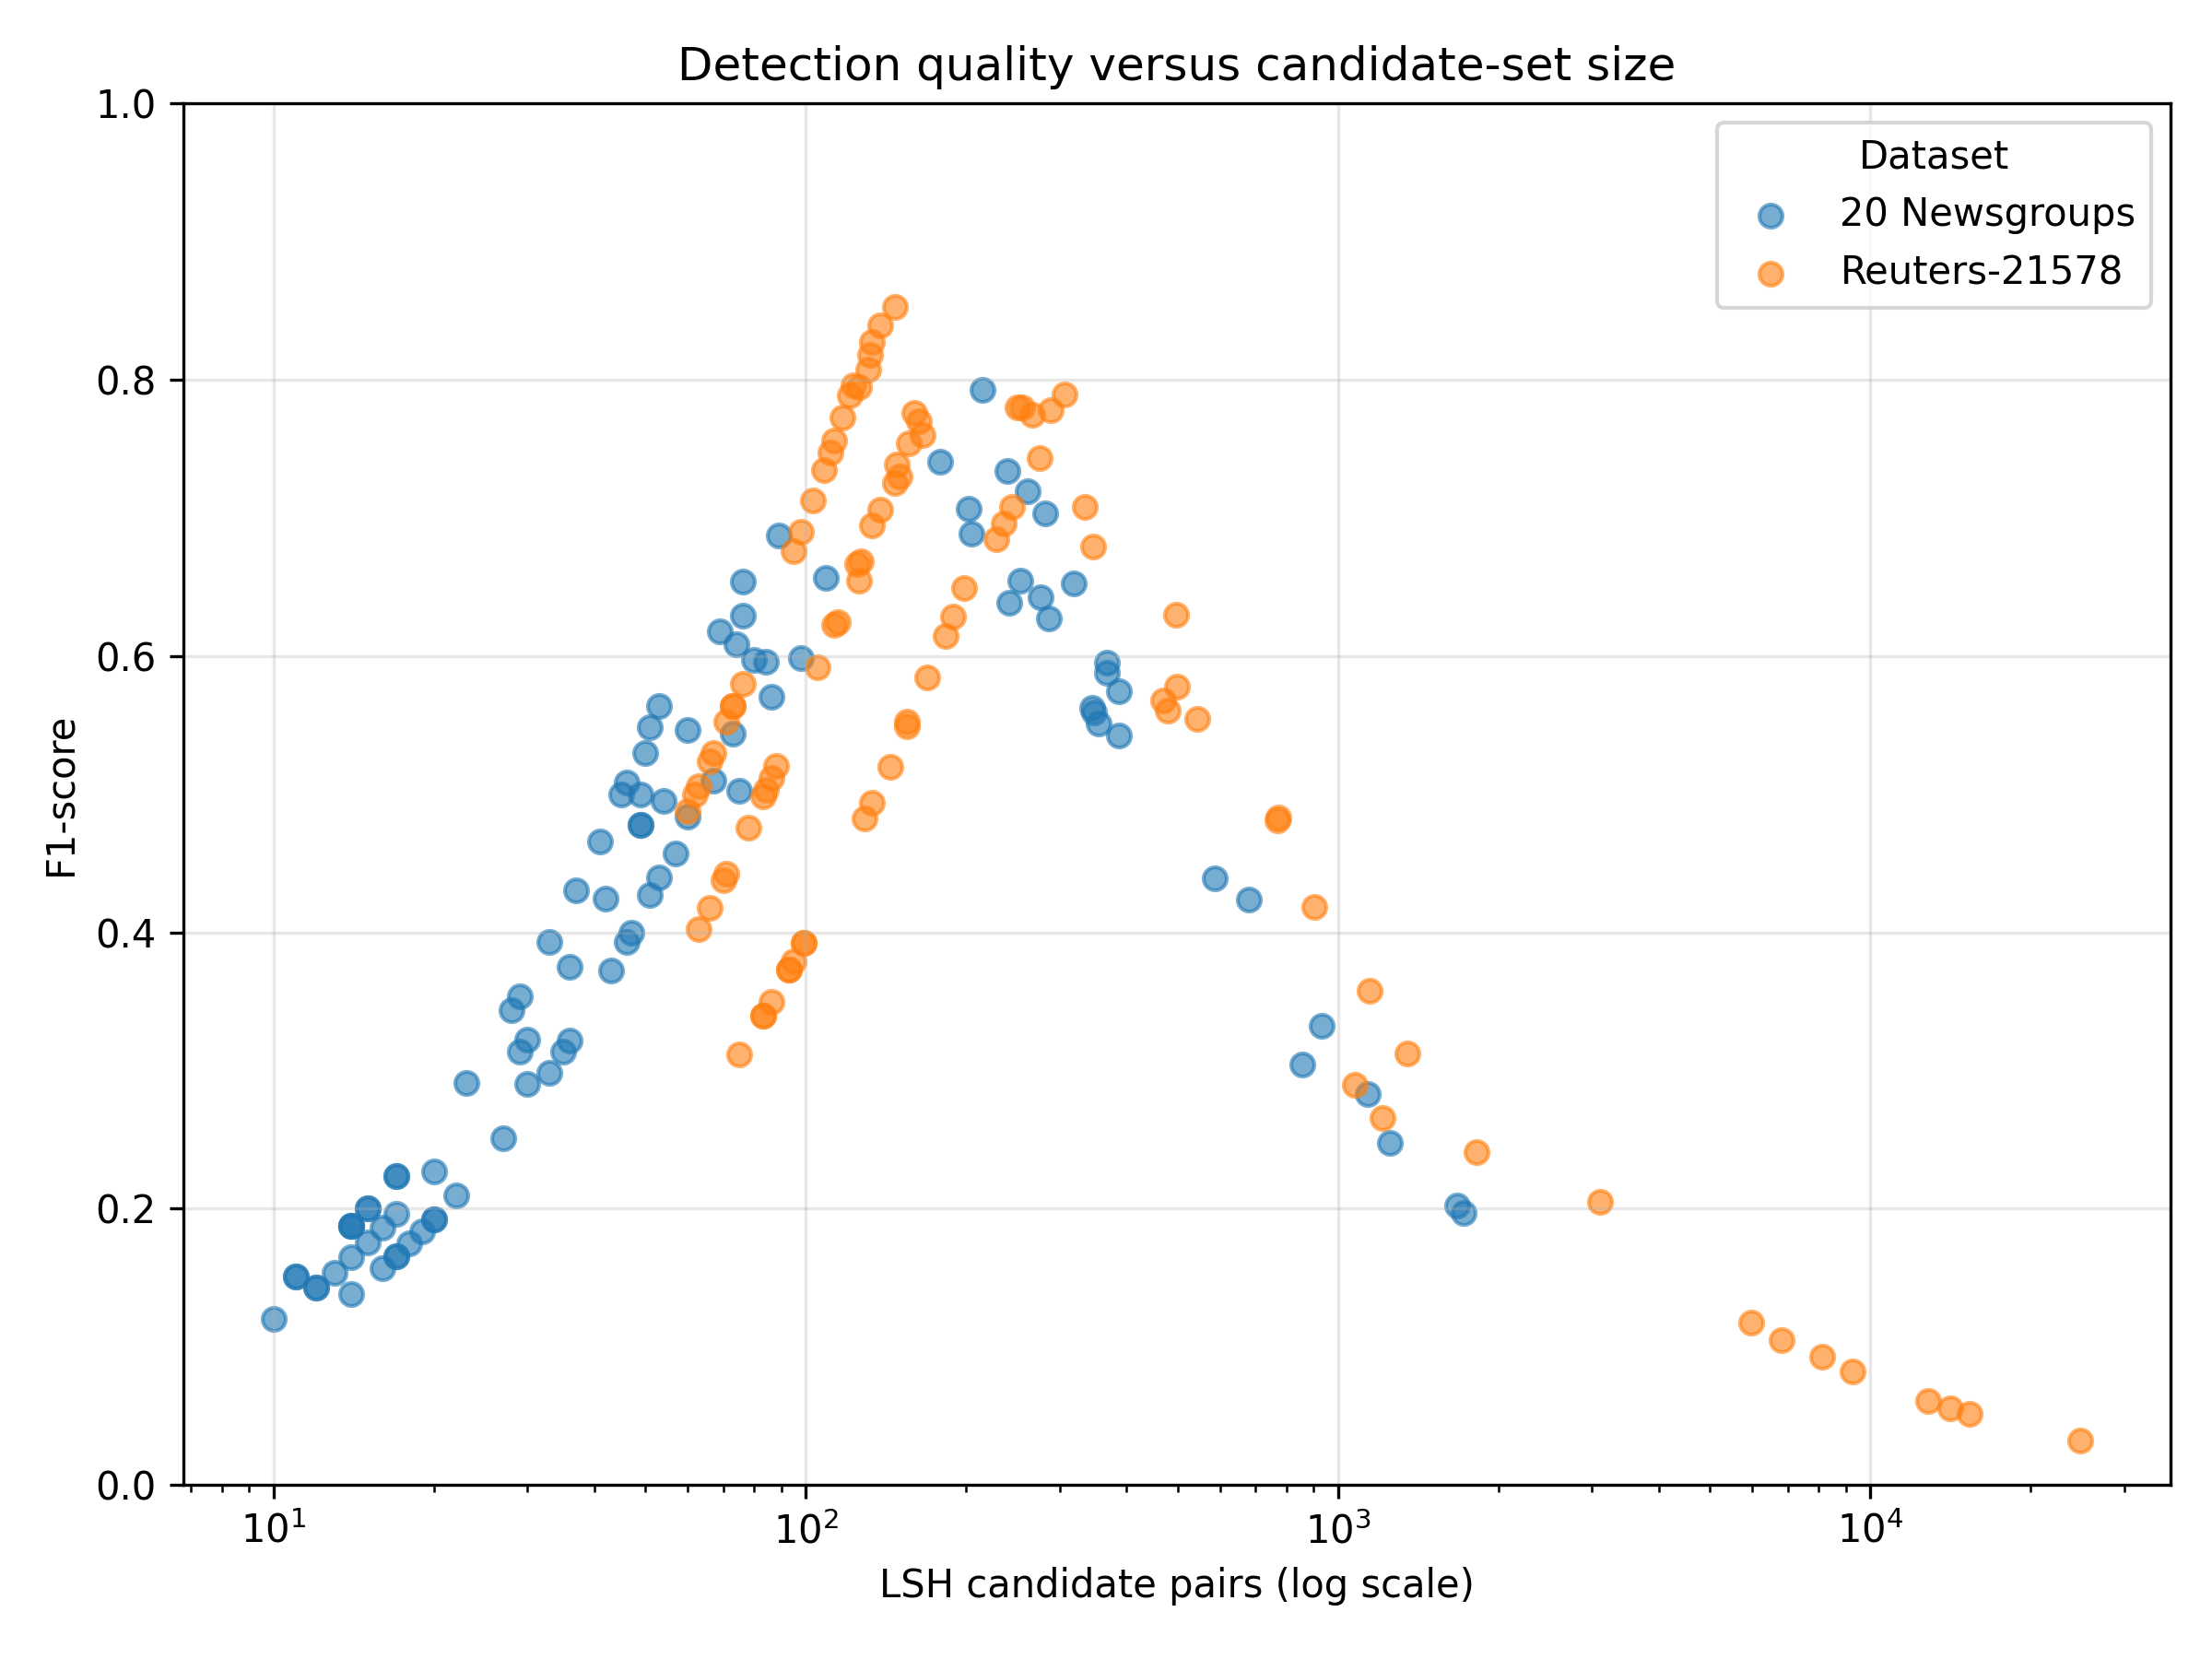

In [20]:
display(
    Image(
        filename=str(
            FIGURES / "final_comparison" / "f1_vs_candidate_pairs.png"
        ),
        width=650
    )
)

The highest F1-scores occur with candidate sets containing only a few hundred pairs, even though each 5,000-document sample contains 12,497,500 possible pairs. Increasing the number of candidates initially helps recover true positives, but very permissive configurations eventually add false positives faster than they improve recall.


## Effect of the main parameters

The next figures show the effect of:

- shingle size `k`
- the LSH banding parameters `b` and `r`
- the number of MinHash values
- the MinHash hash family

For the controlled comparisons, the other parameters are kept fixed. MurmurHash is used as the fixed baseline for the shingle-size and banding plots so that the effect of the selected parameter can be seen clearly.

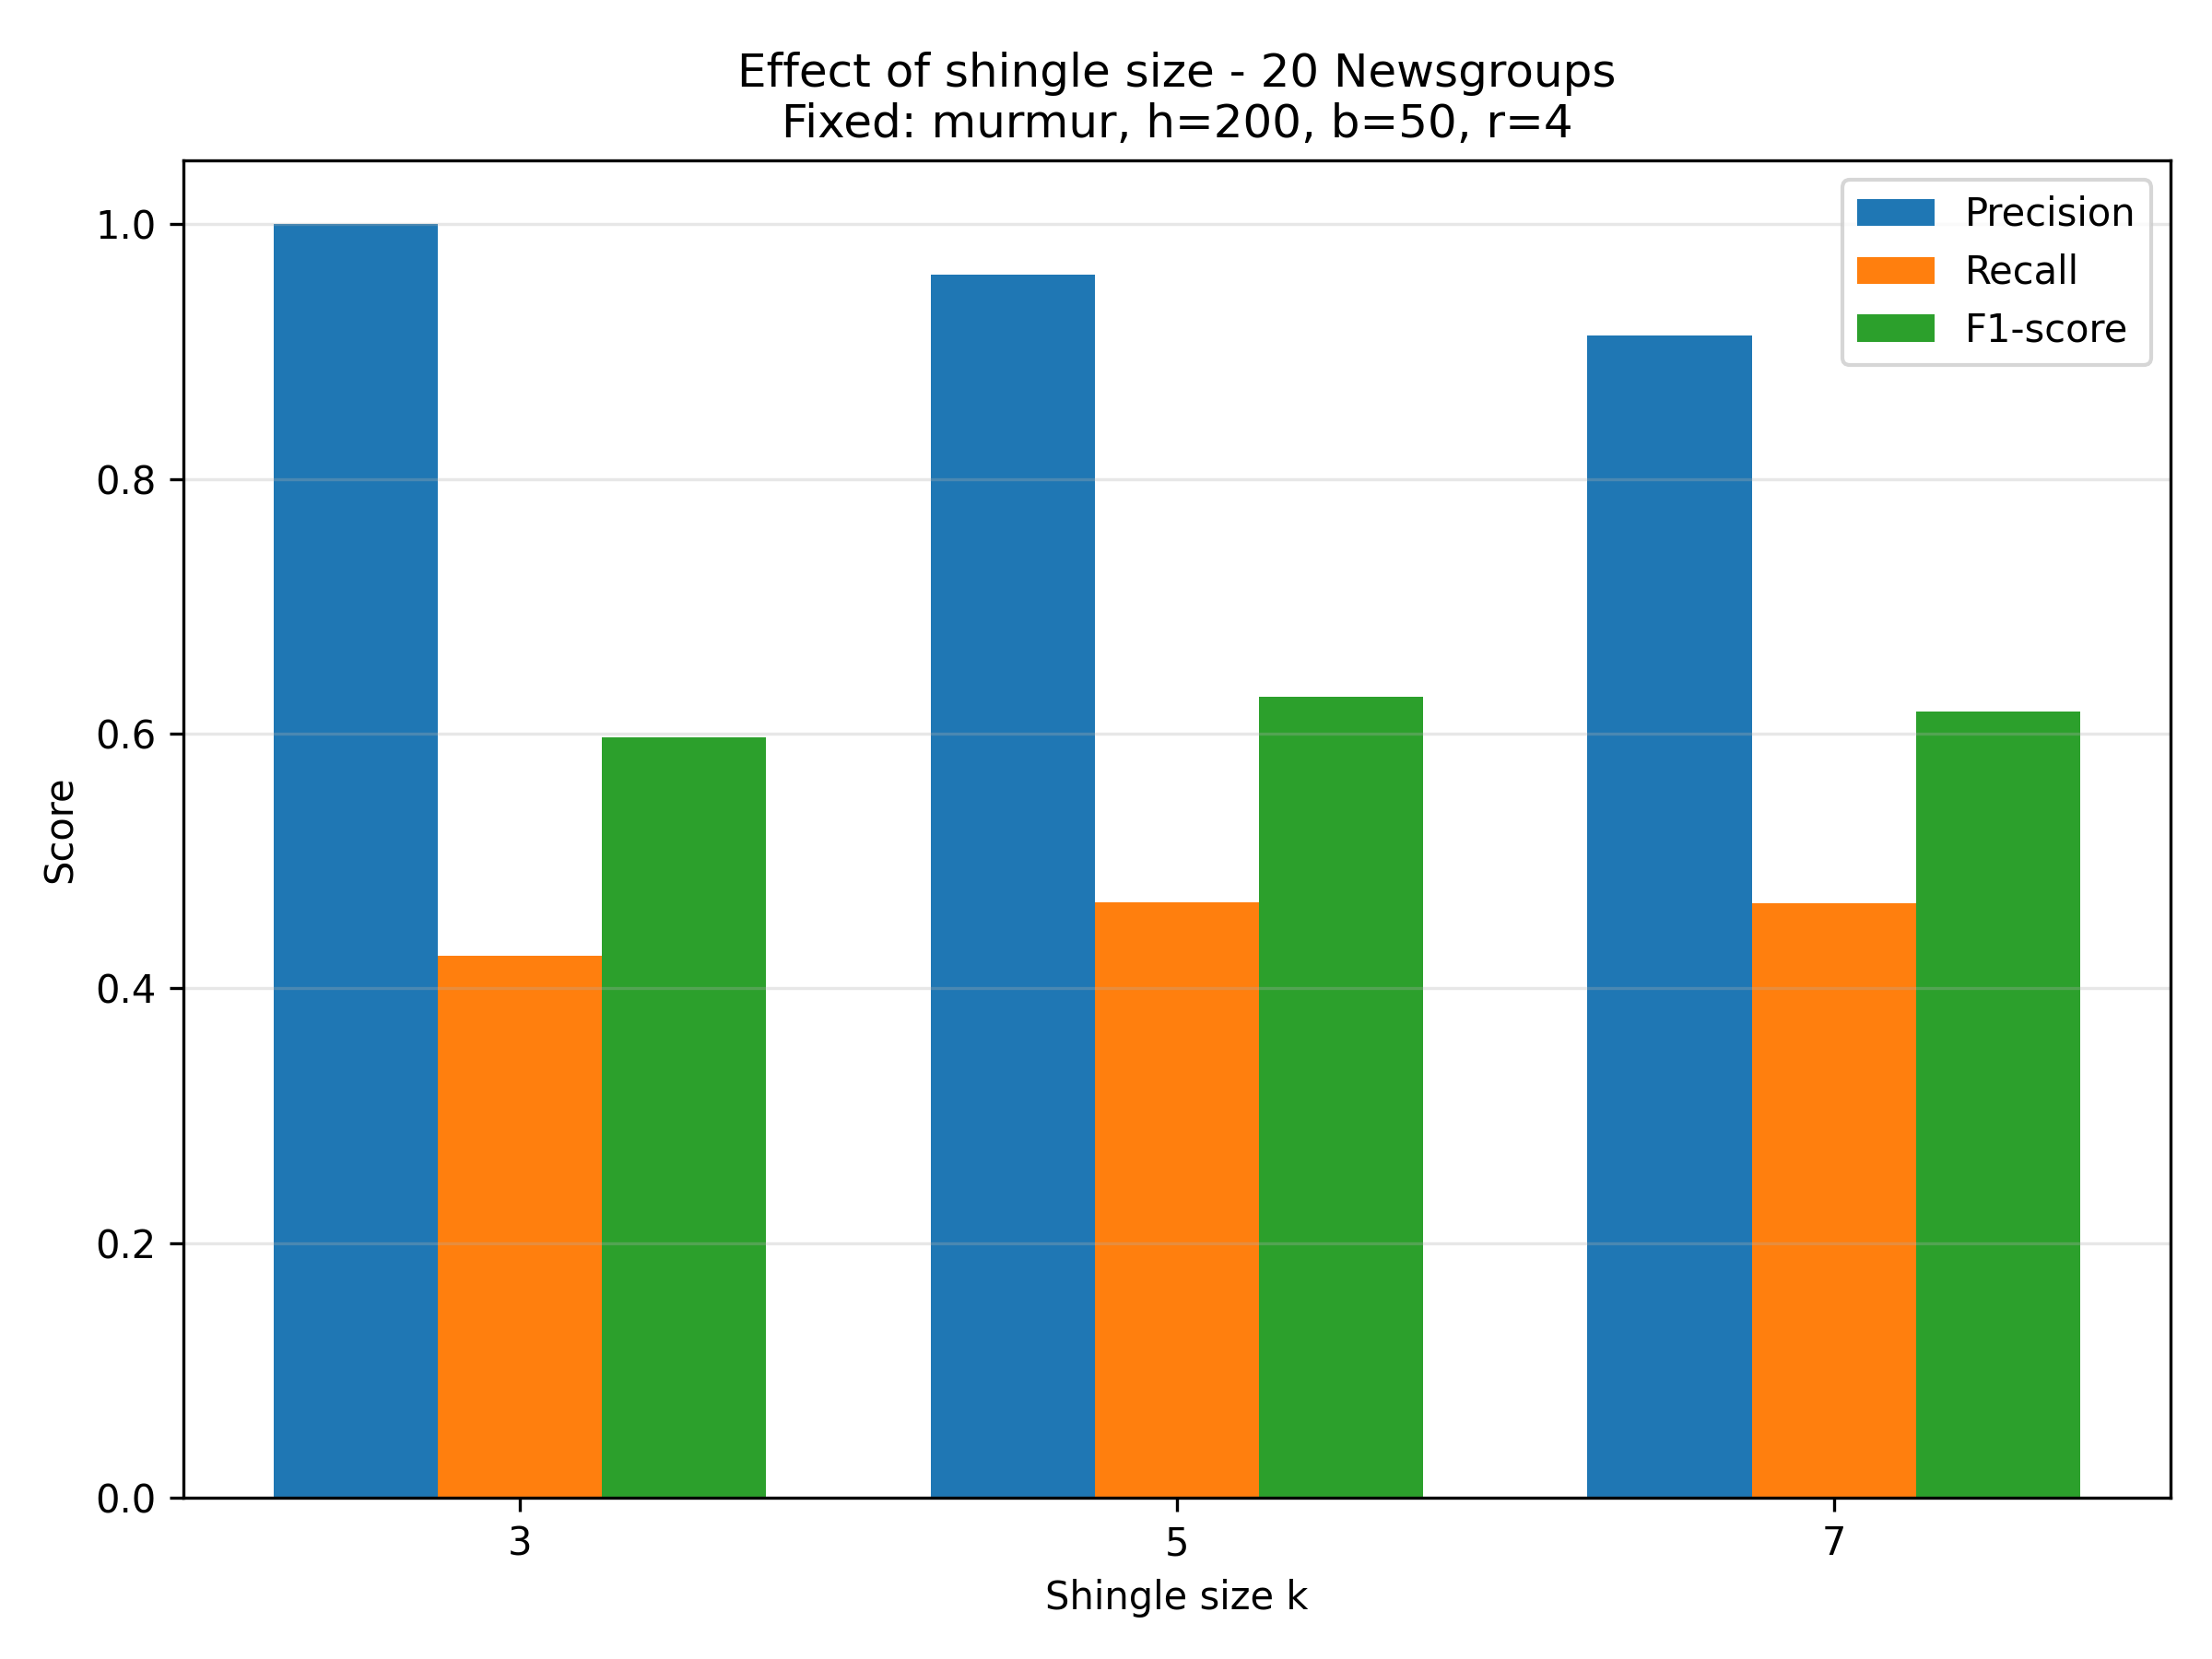

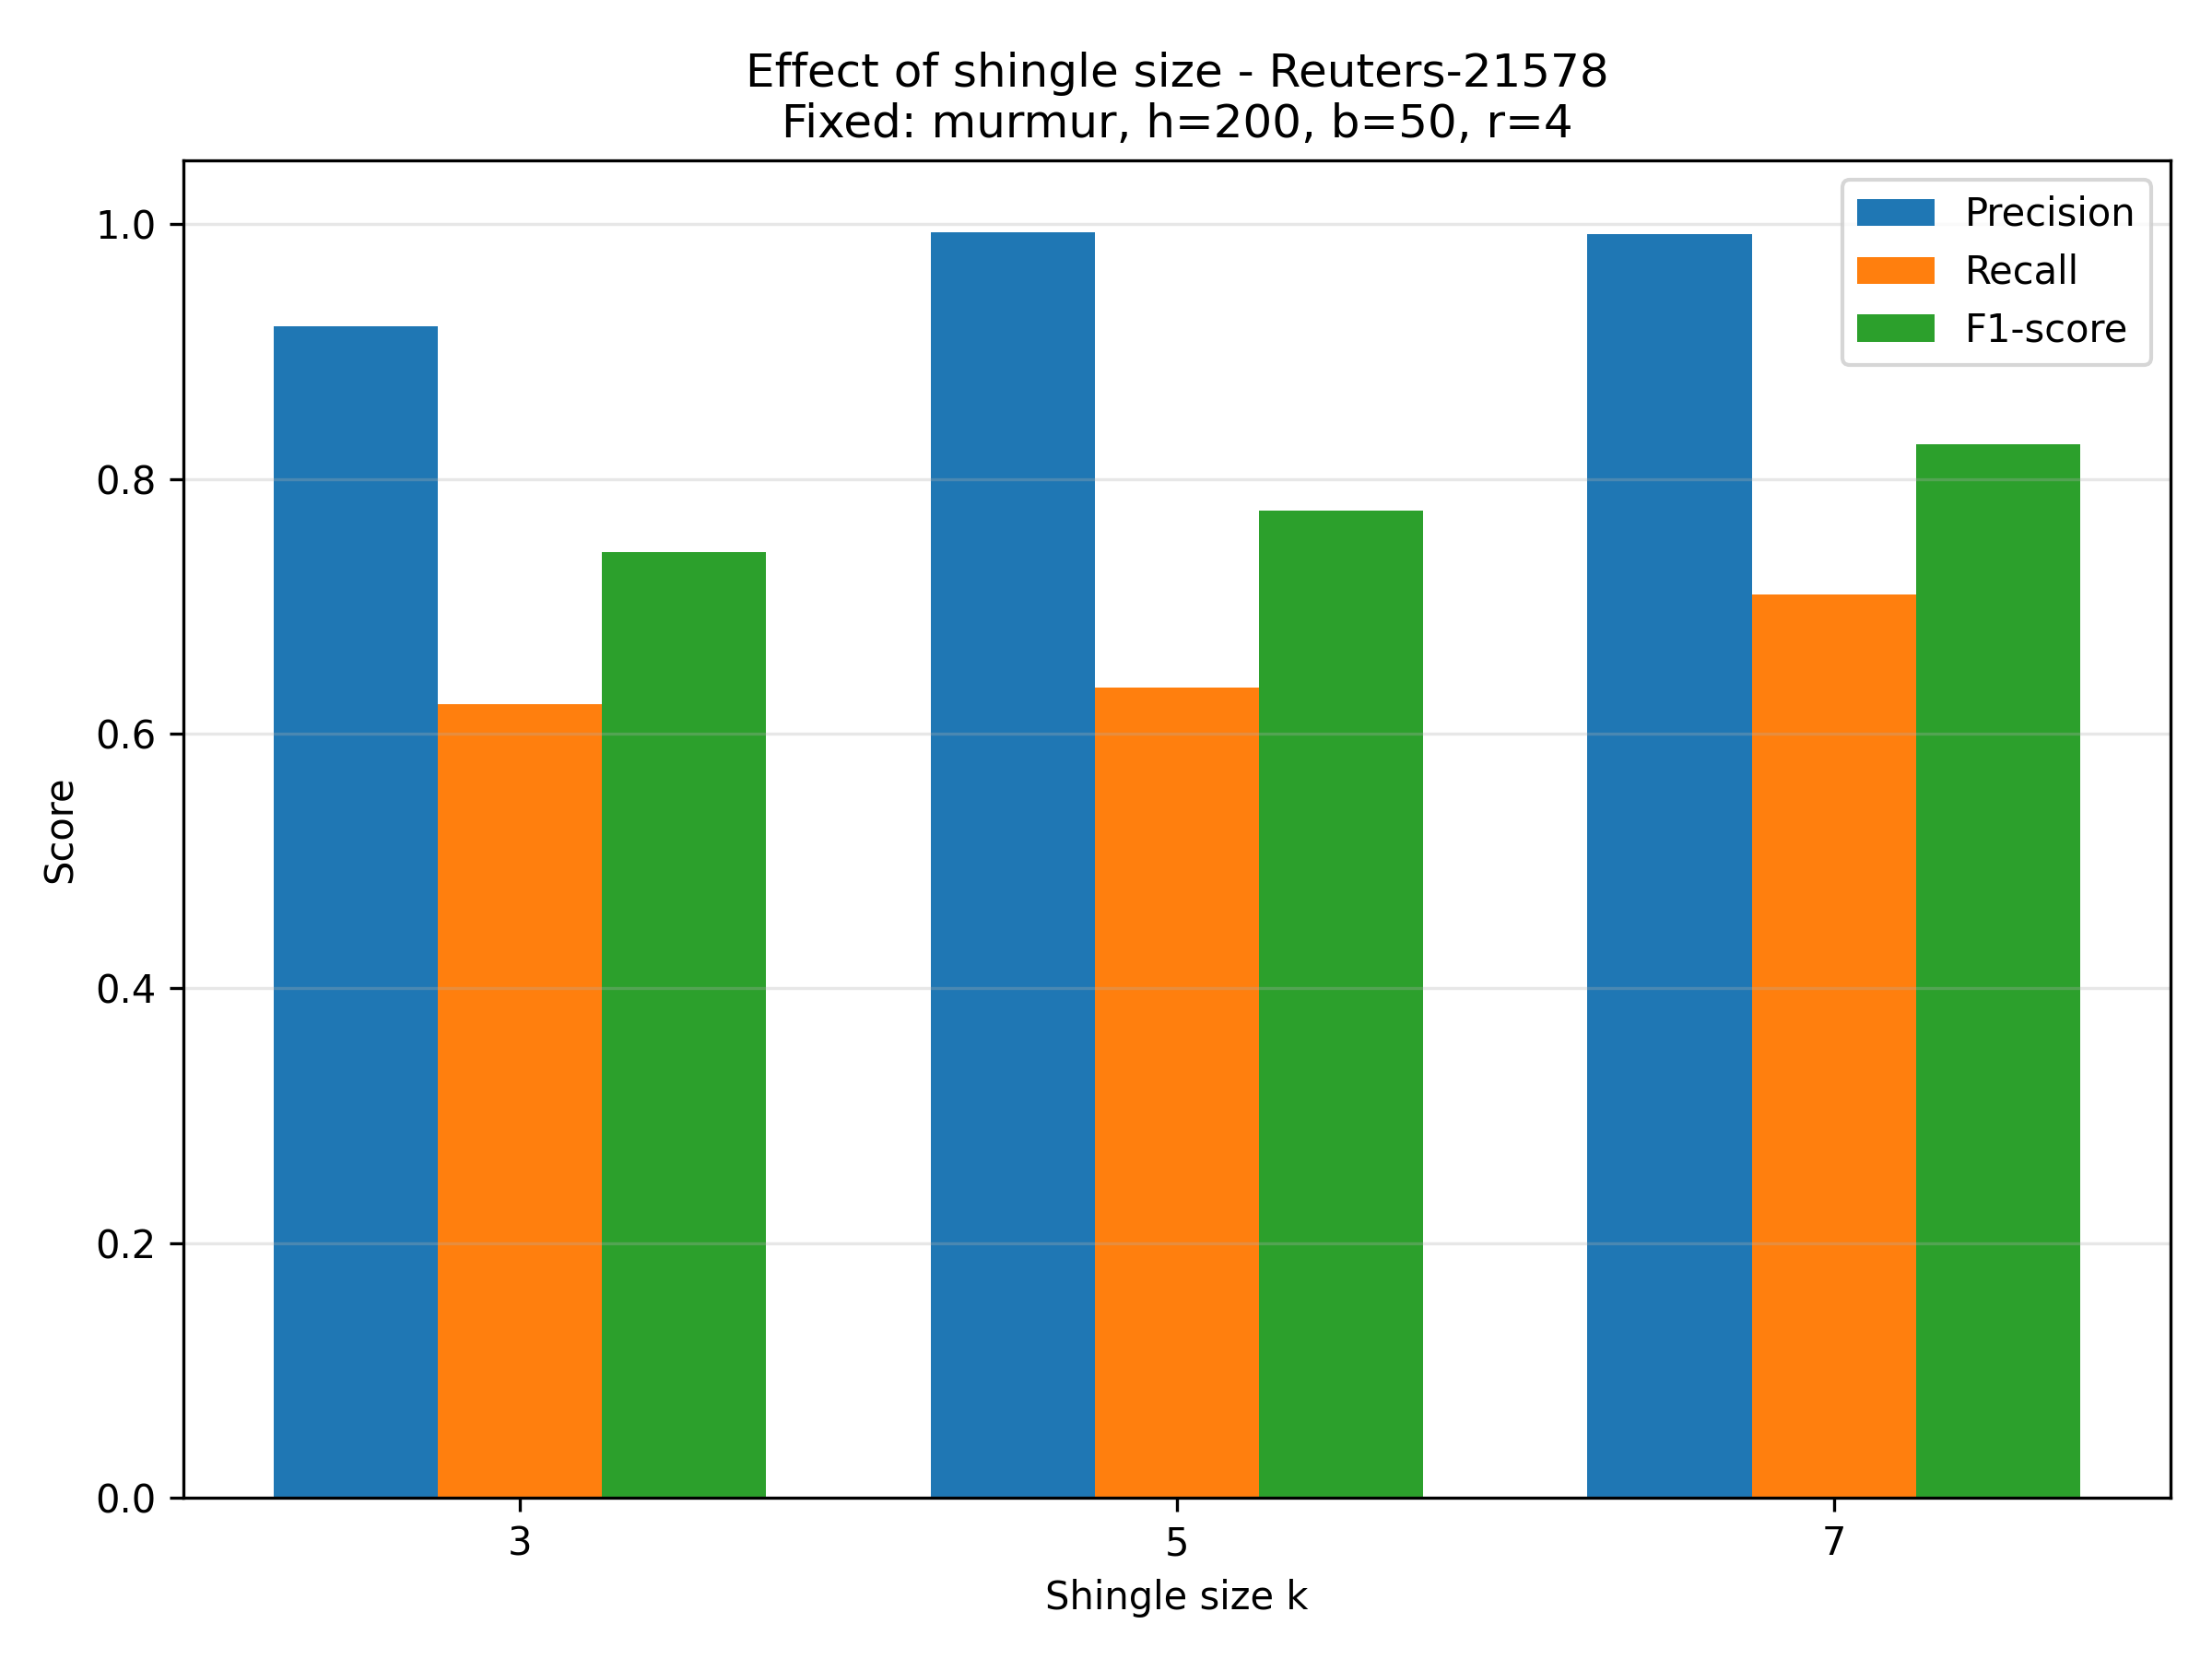

In [21]:
display(
    Image(
        filename=str(
            FIGURES / "final_20_newsgroups" / "effect_of_k.png"
        ),
        width=600
    )
)
display(
    Image(
        filename=str(
            FIGURES / "final_reuters" / "effect_of_k.png"
        ),
        width=600
    )
)

With the other parameters fixed, k = 5 gives the highest F1-score on 20 Newsgroups, while k = 7 performs best on Reuters-21578. This shows that the preferred shingle size depends on the dataset.

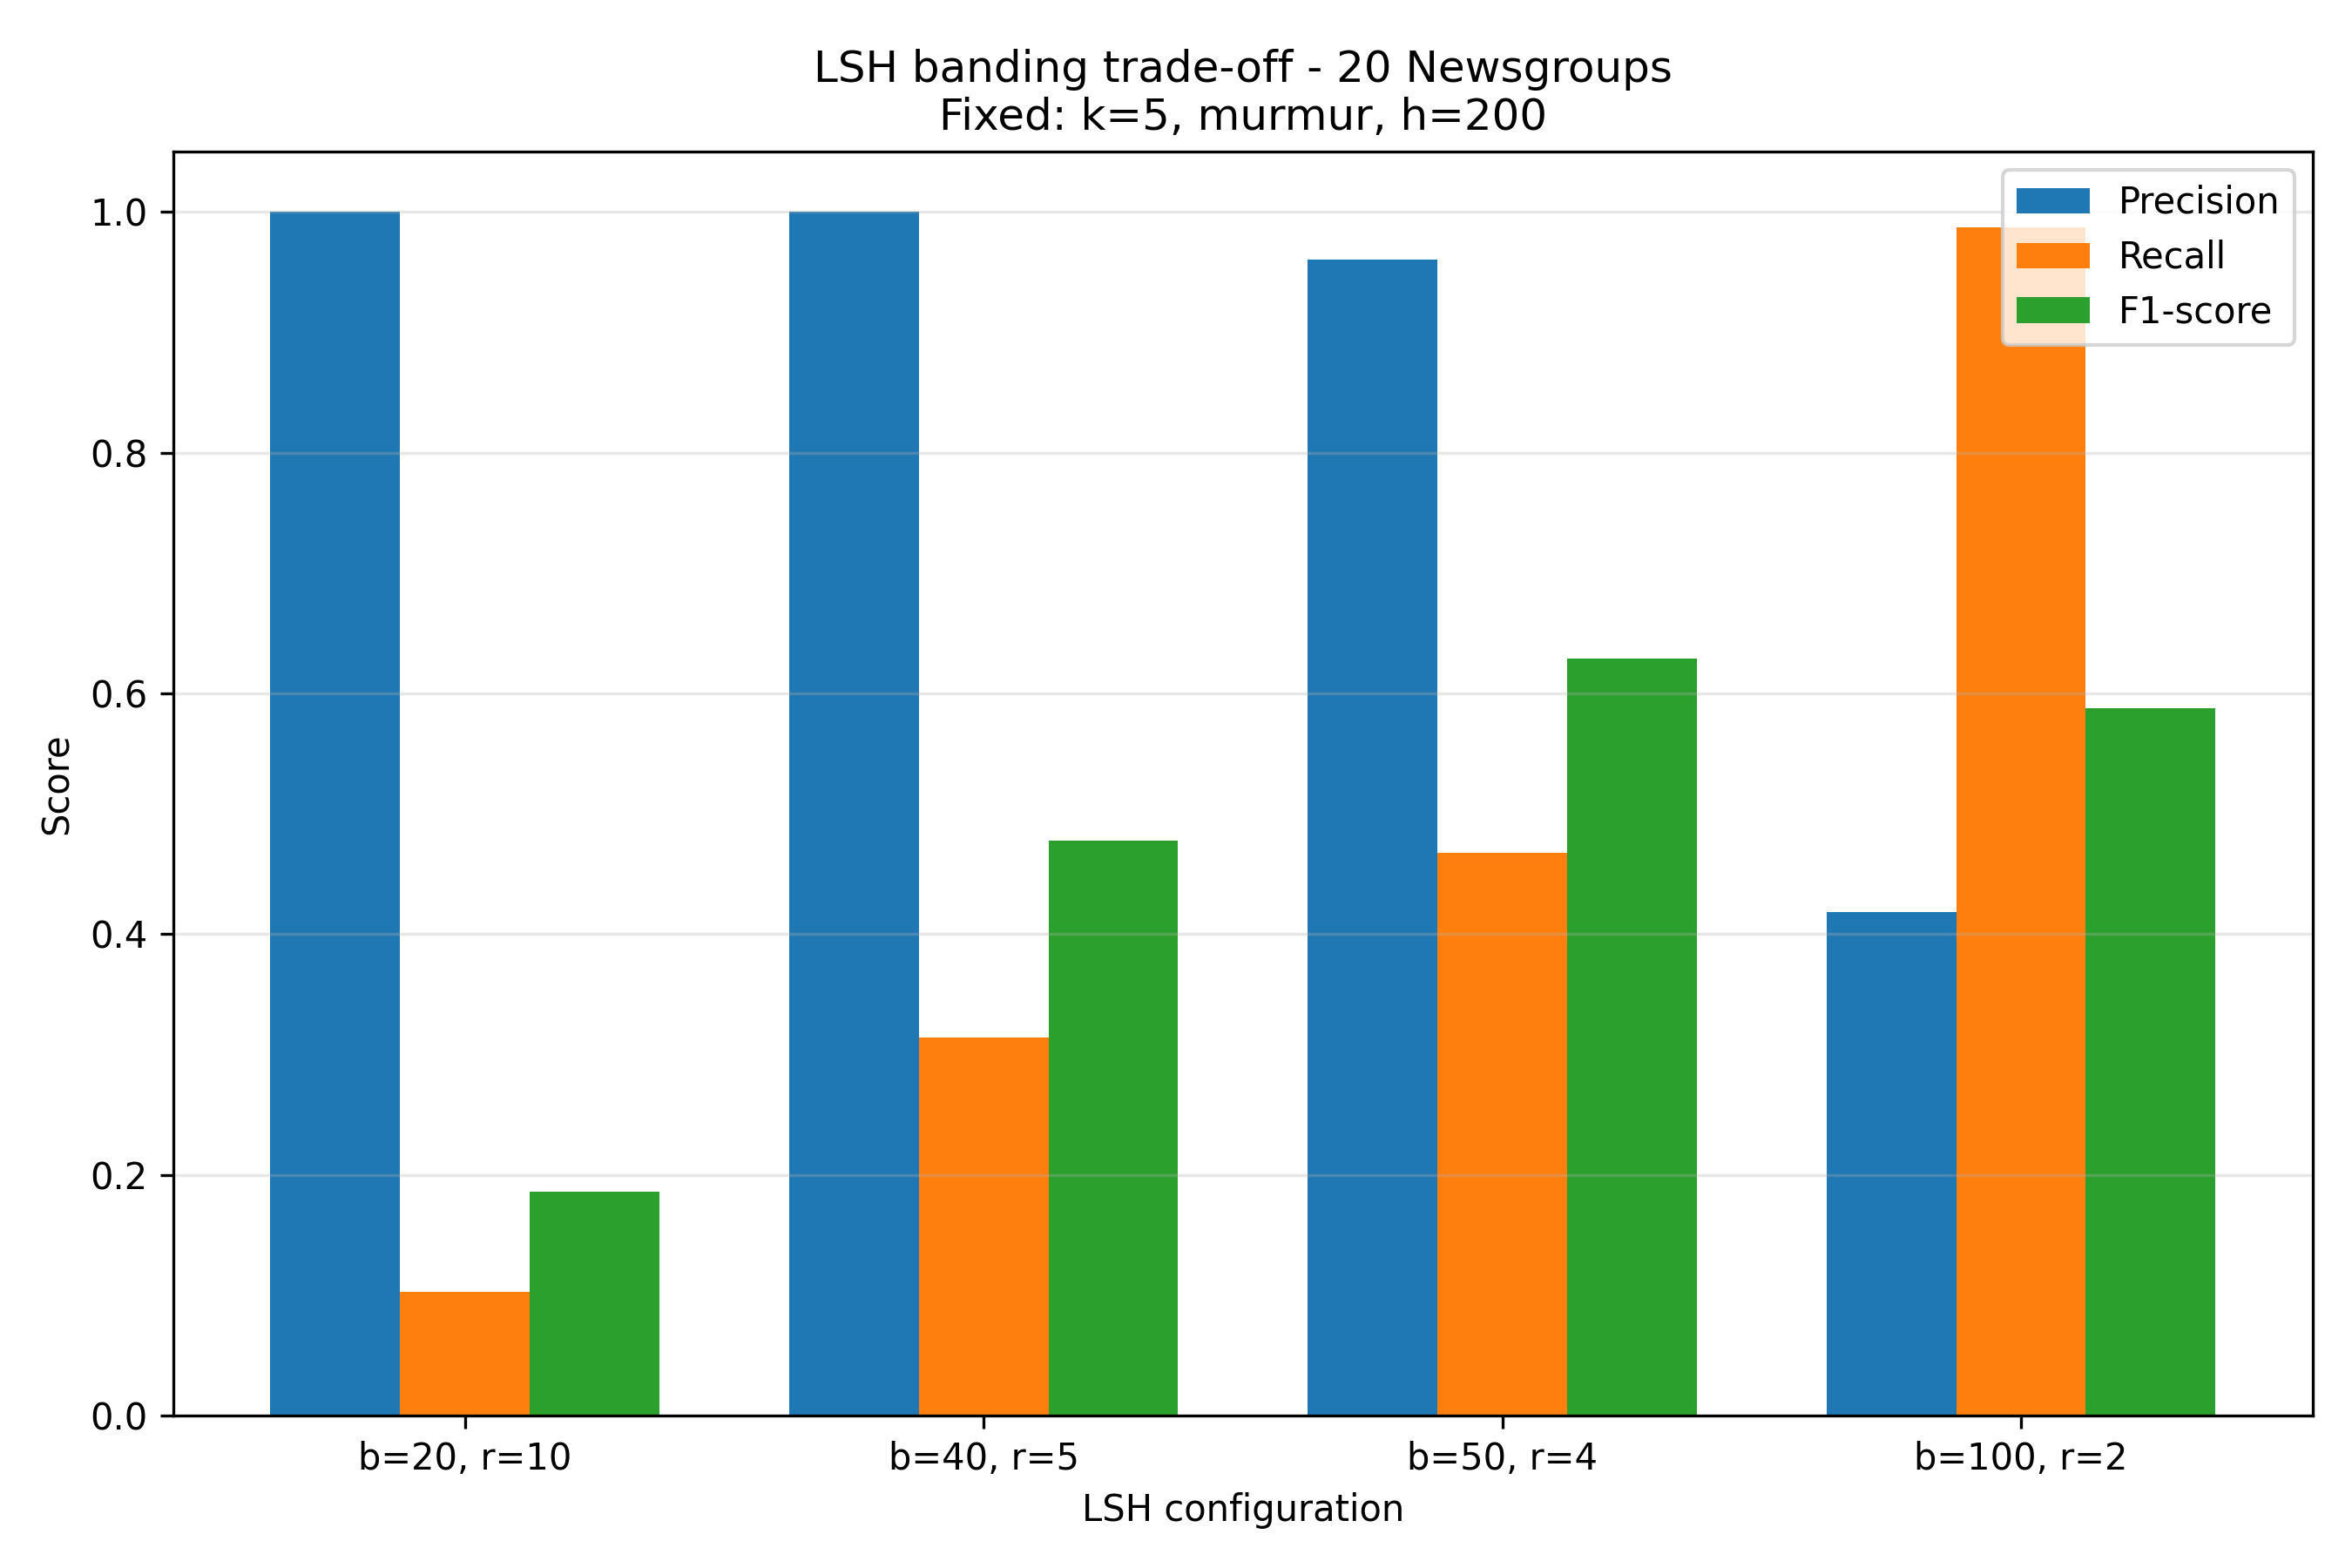

In [22]:
display(
    Image(
        filename=str(
            FIGURES
            / "final_20_newsgroups"
            / "lsh_banding_tradeoff.png"
        ),
        width=650
    )
)

The banding results show the expected trade-off. Tall bands such as b = 20, r = 10 produce almost perfect precision but miss many positive pairs. Shorter bands such as b = 100, r = 2 recover almost every positive pair but produce many false positives. The intermediate b = 50, r = 4 configuration gives the strongest balance among the four displayed settings.

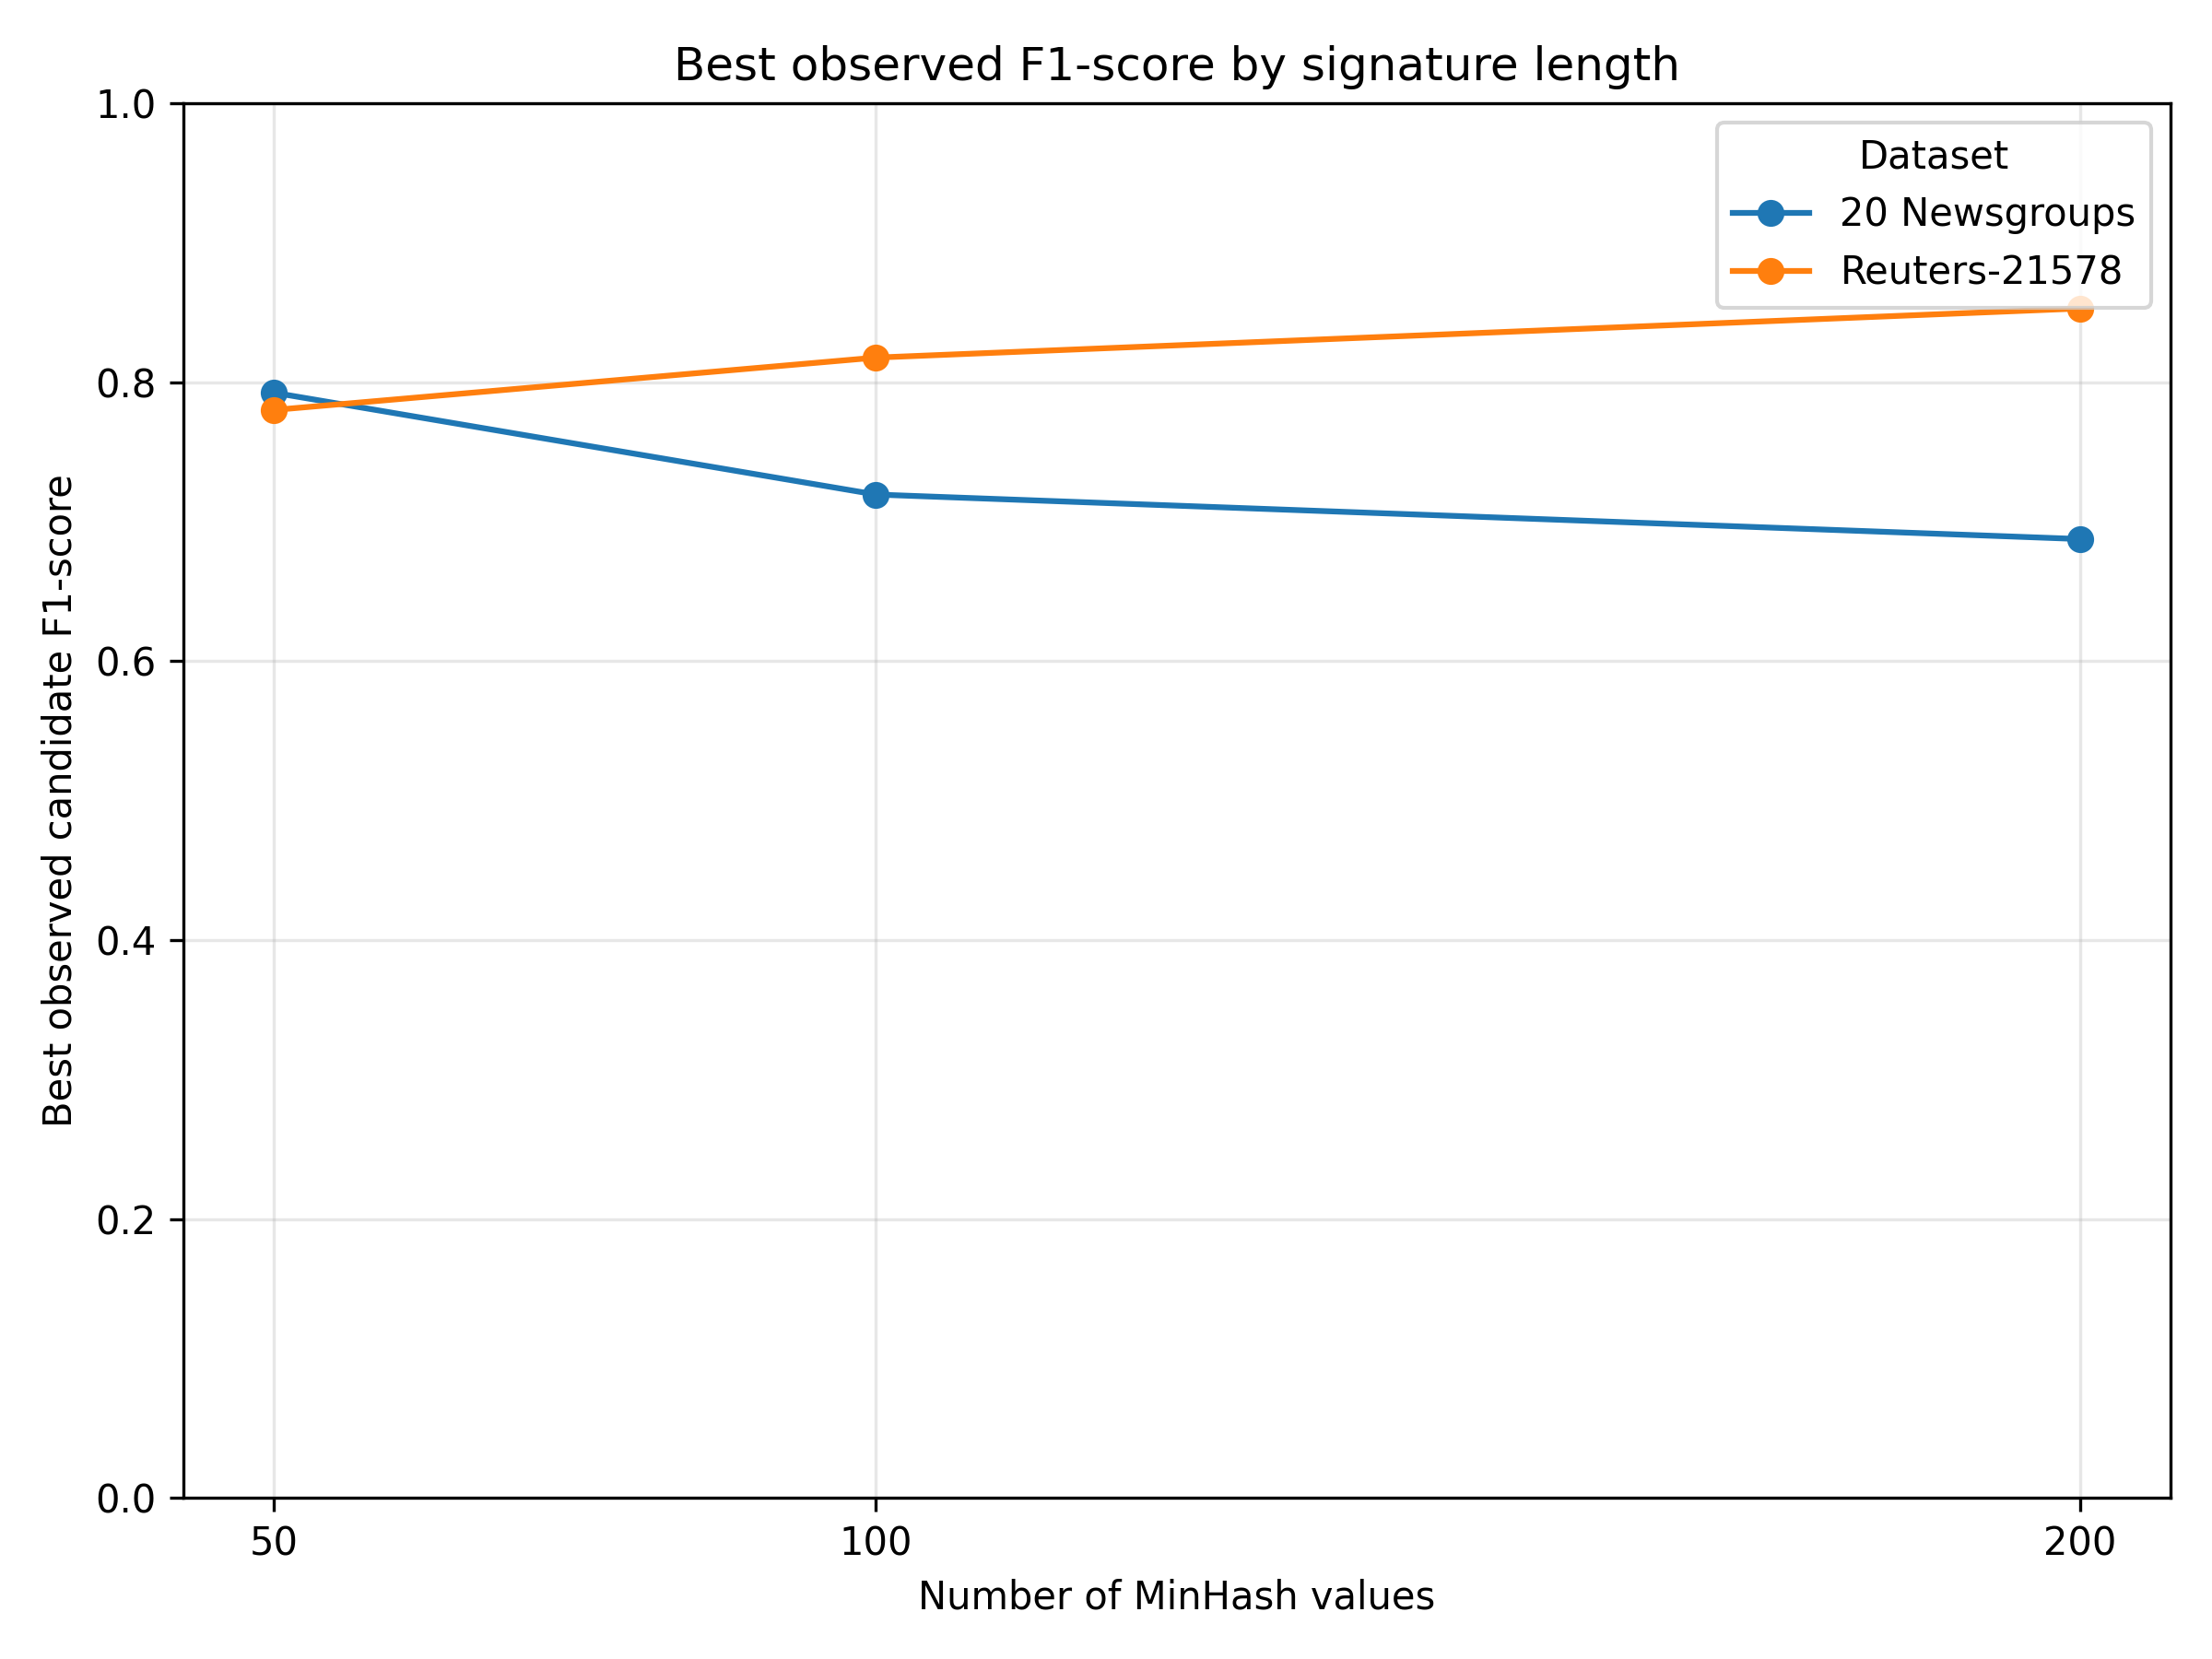

In [23]:
display(
    Image(
        filename=str(
            FIGURES
            / "final_comparison"
            / "best_f1_by_signature_length.png"
        ),
        width=600
    )
)

The signature-length trends differ between the datasets. The best Reuters-21578 F1-score increases from 0.780 at 50 hashes to 0.853 at 200 hashes, while the best 20 Newsgroups score decreases from 0.792 to 0.688. Because every value is the maximum over other parameters, this plot shows interaction between signature length and banding rather than the isolated effect of adding hash values.

In [10]:
hash_family_summary = (
    results[
        (results["k"] == 5)
        & (results["num_hashes"] == 200)
        & (results["num_bands"] == 50)
        & (results["rows_per_band"] == 4)
    ]
    .pivot(
        index="hash_family",
        columns="dataset",
        values="f1_score",
    )
    .rename(
        index={
            "linear": "Linear",
            "murmur": "MurmurHash",
            "tabulation": "Tabulation",
        },
        columns={
            "20_newsgroups": "20 Newsgroups",
            "reuters": "Reuters-21578",
        },
    )
    .rename_axis(index="Hash family", columns=None)
    .round(3)
)

hash_family_summary

,20 Newsgroups,Reuters-21578
Hash family,,
Linear,0.609,0.760
MurmurHash,0.629,0.776
Tabulation,0.657,0.770


With k = 5, h = 200, b = 50 and r = 4 fixed, the three hash families give similar F1-scores. Tabulation performs best on 20 Newsgroups, while MurmurHash performs best on Reuters-21578. The differences are small, so this does not show that one hash family is always better.

## S-curve validation

The controlled experiment creates pairs across the full Jaccard range. The natural experiment uses real document pairs.

The controlled curve is the clearest comparison with theory. The natural curve is less smooth because highly similar real documents are rare.

In [11]:
controlled = pd.read_csv(
    TABLES / "s_curve_controlled_20_newsgroups.csv"
)
natural = pd.read_csv(
    TABLES / "s_curve_natural_20_newsgroups.csv"
)

summary = pd.DataFrame(
    {
        "experiment": ["controlled", "natural"],
        "mean_absolute_gap": [
            controlled["absolute_gap"].mean(),
            natural.loc[natural["num_pairs"] >= 10, "absolute_gap"].mean(),
        ],
    }
)

summary

,experiment,mean_absolute_gap
0,controlled,0.008469
1,natural,0.019842


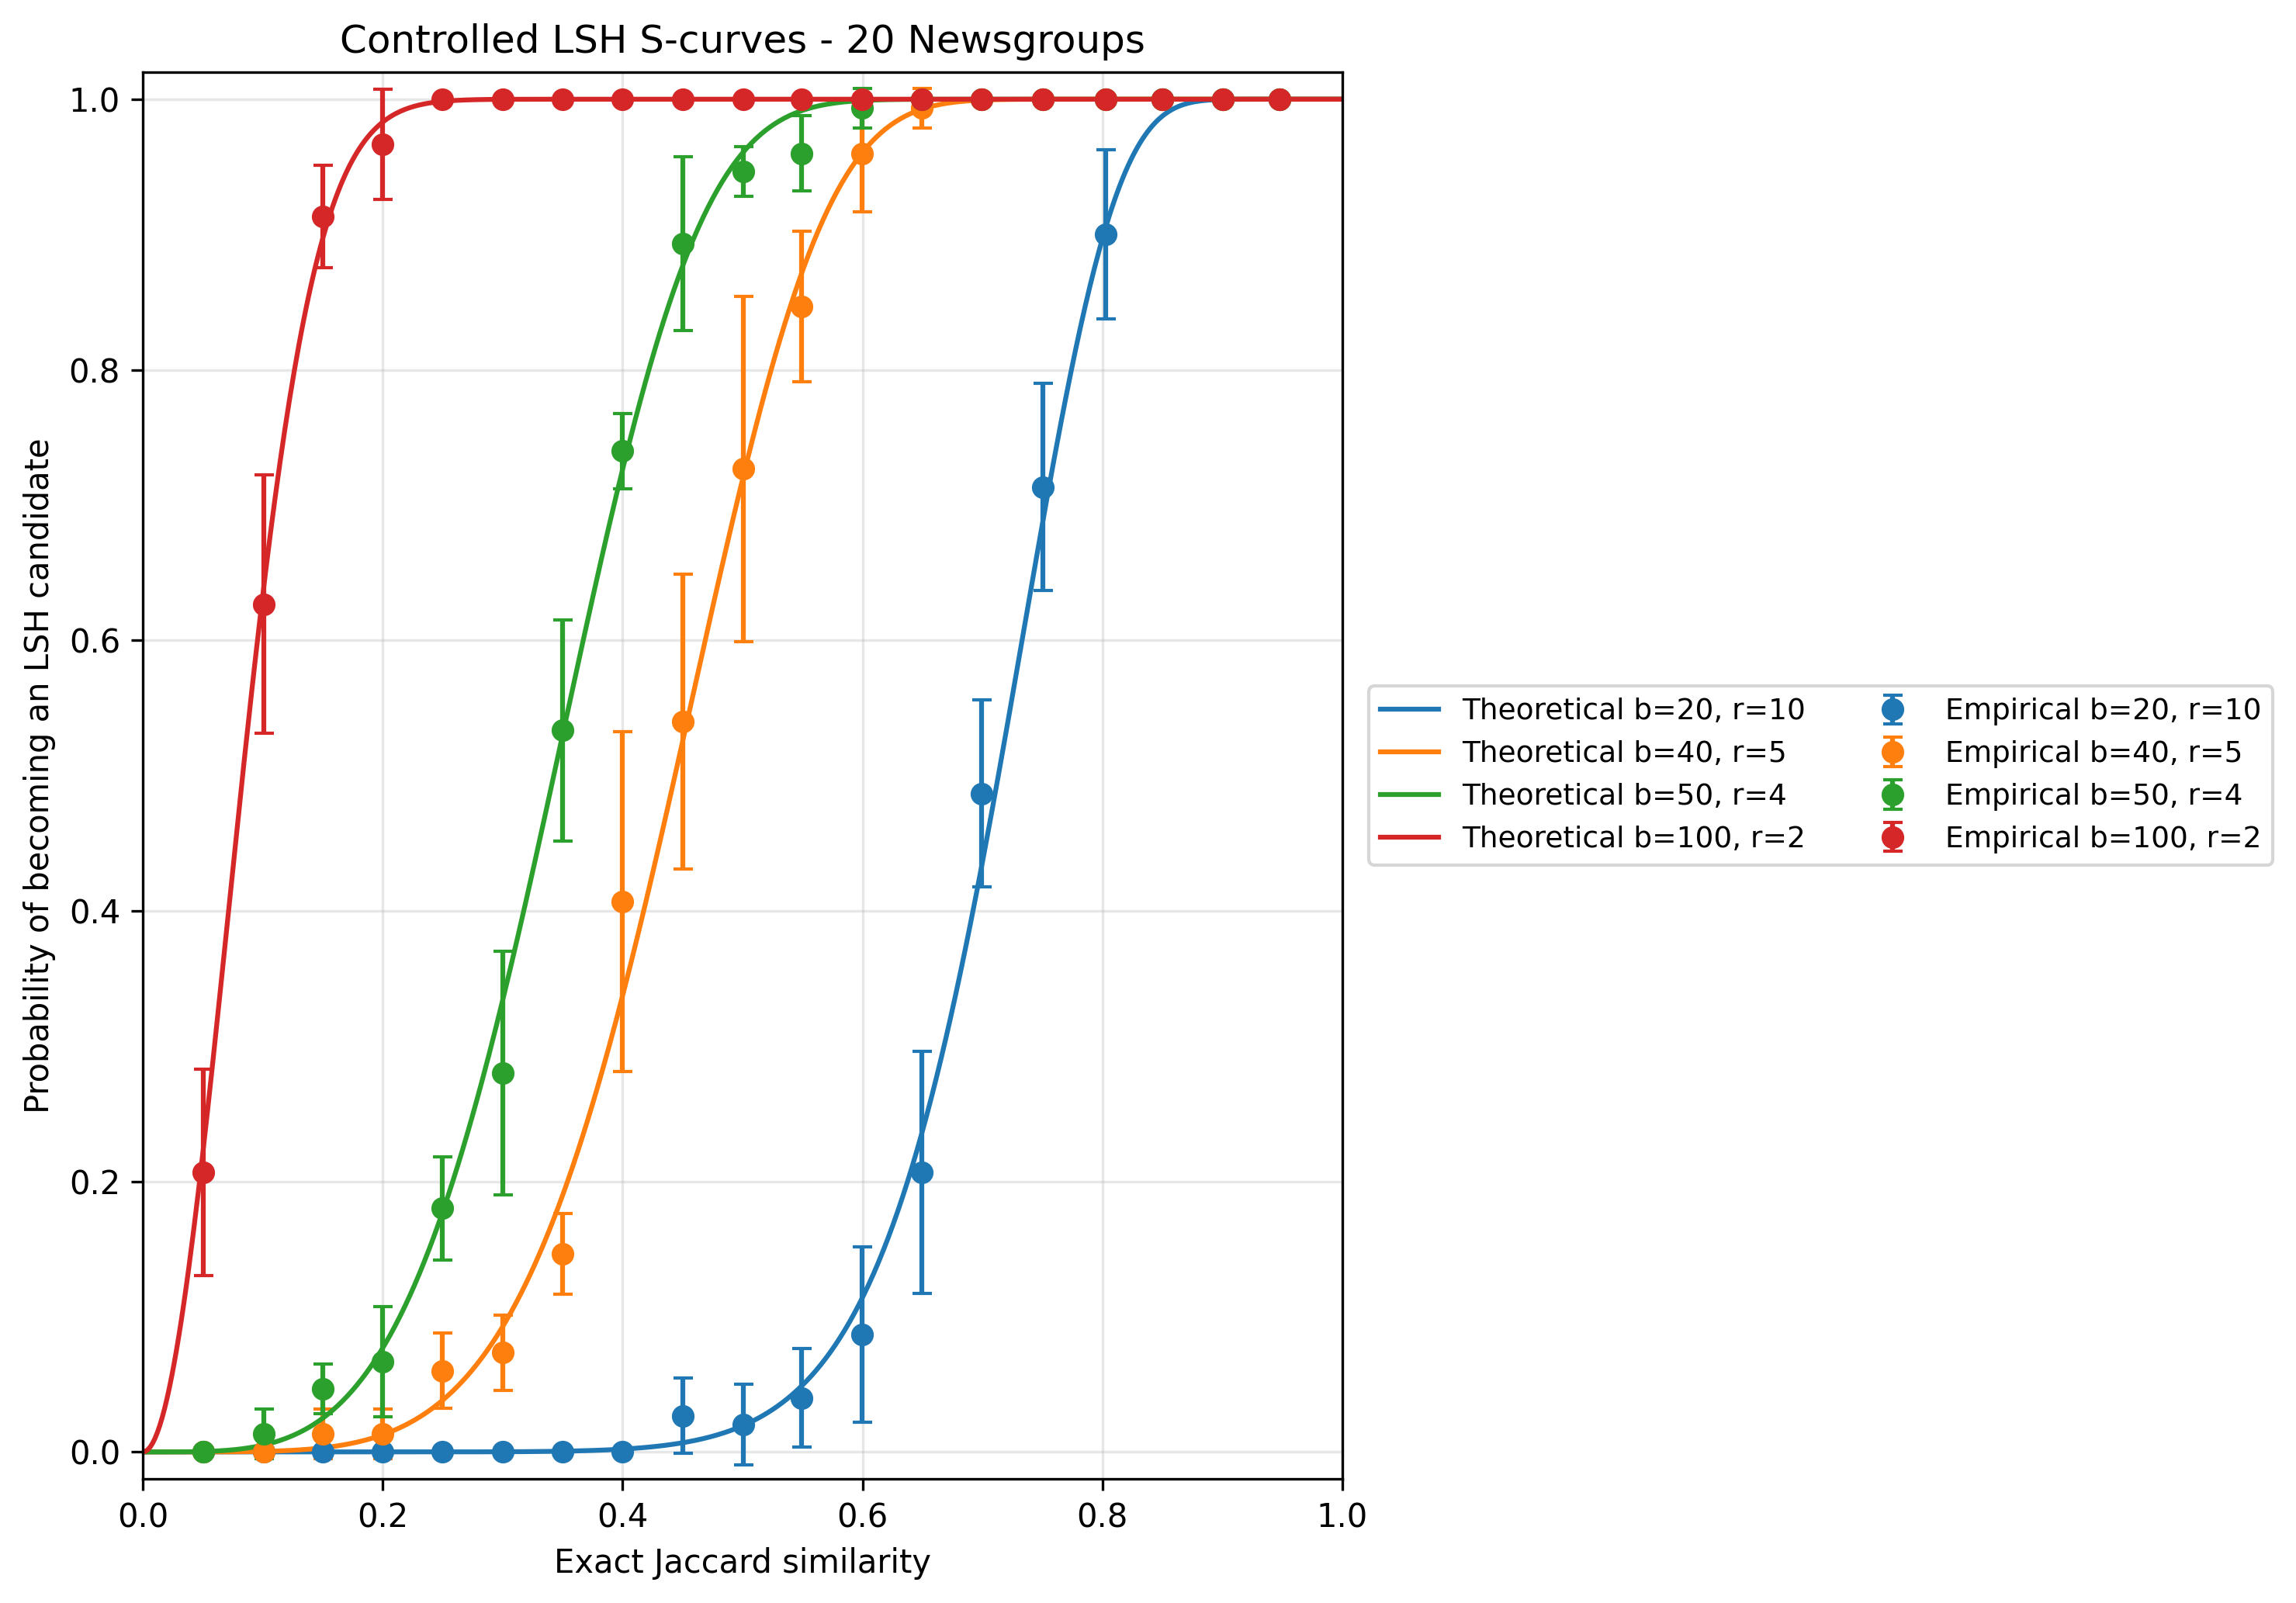

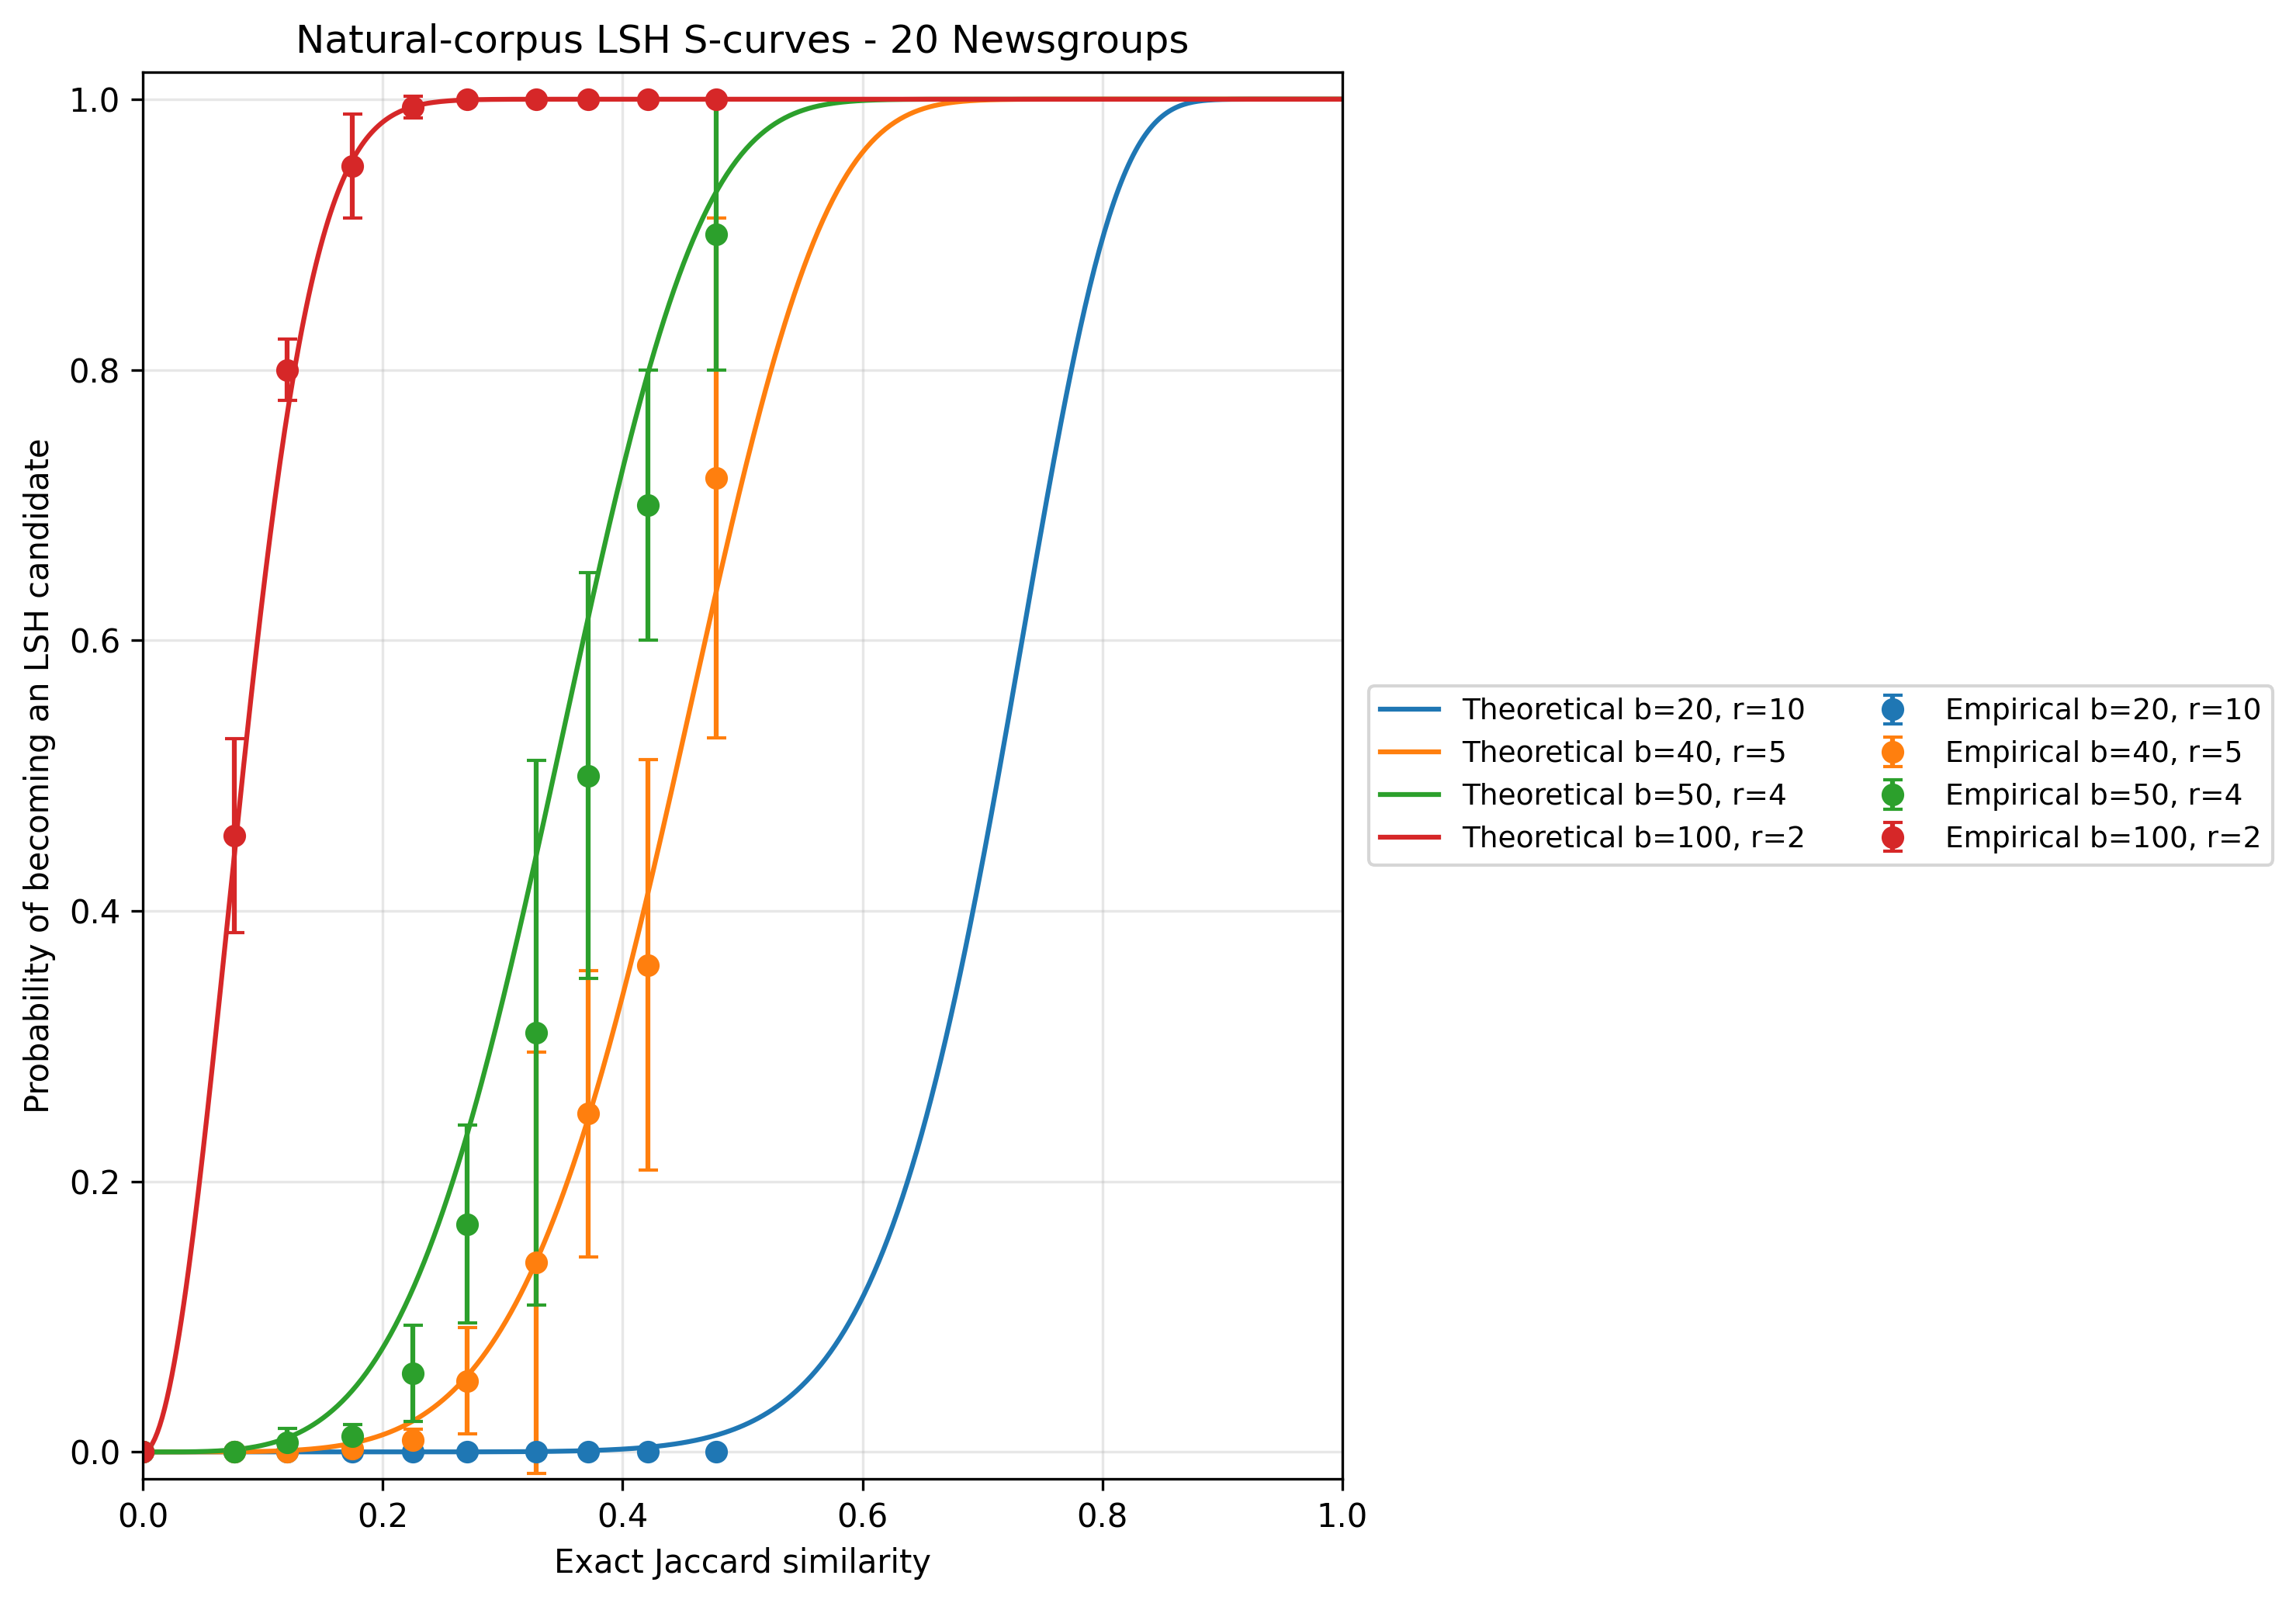

In [29]:
display(Image(filename=str(FIGURES / "final_20_newsgroups" / "s_curve_controlled.png"),width=650))
display(Image(filename=str(FIGURES / "final_20_newsgroups" / "s_curve_natural.png"),width=650))

For 20 Newsgroups, the controlled empirical collision probabilities closely follow the theoretical LSH curves, with a mean absolute gap of 0.0085. The natural-corpus curve is less smooth because highly similar pairs are uncommon and the number of observations differs across similarity bins.

## MinHash validation

The custom MinHash implementations are compared with exact Jaccard similarity and with `datasketch`.

The validation uses a fixed sample of 1,000 20 Newsgroups documents with k = 5. Pairs with exact Jaccard similarity of at least 0.05 are treated as similar. The code allows up to 100 similar pairs, but only 22 pairs in this sample meet the threshold. Another 100 pairs below 0.05 are sampled as dissimilar.

Each method is tested with 50, 100 and 200 hash values using five hash seeds.

The main expected result is that estimation error decreases as the signature length grows.

In [13]:
validation = pd.read_csv(
    TABLES / "datasketch_validation_summary.csv"
)

validation[
    validation["pair_type"] == "similar"
][
    [
        "method",
        "num_hashes",
        "mean_absolute_error",
        "mae_standard_deviation",
        "correlation",
    ]
].sort_values(["method", "num_hashes"])

,method,num_hashes,mean_absolute_error,mae_standard_deviation,correlation
1,datasketch,50,0.037227,0.009269,0.886601
4,datasketch,100,0.025620,0.004891,0.953651
7,datasketch,200,0.019170,0.004371,0.970318
10,linear,50,0.036139,0.007762,0.911882
13,linear,100,0.026289,0.004362,0.950326
16,linear,200,0.019499,0.003754,0.970776
19,murmur,50,0.035628,0.006143,0.917454
22,murmur,100,0.028919,0.002150,0.939657
25,murmur,200,0.018375,0.003067,0.974042
28,tabulation,50,0.038316,0.012336,0.910732


The table shows the results for the 22 similar pairs. Lower mean absolute error means a more accurate estimate. The standard deviation shows how much the error changes across the five hash seeds, while correlation shows how closely the estimates follow exact Jaccard similarity.

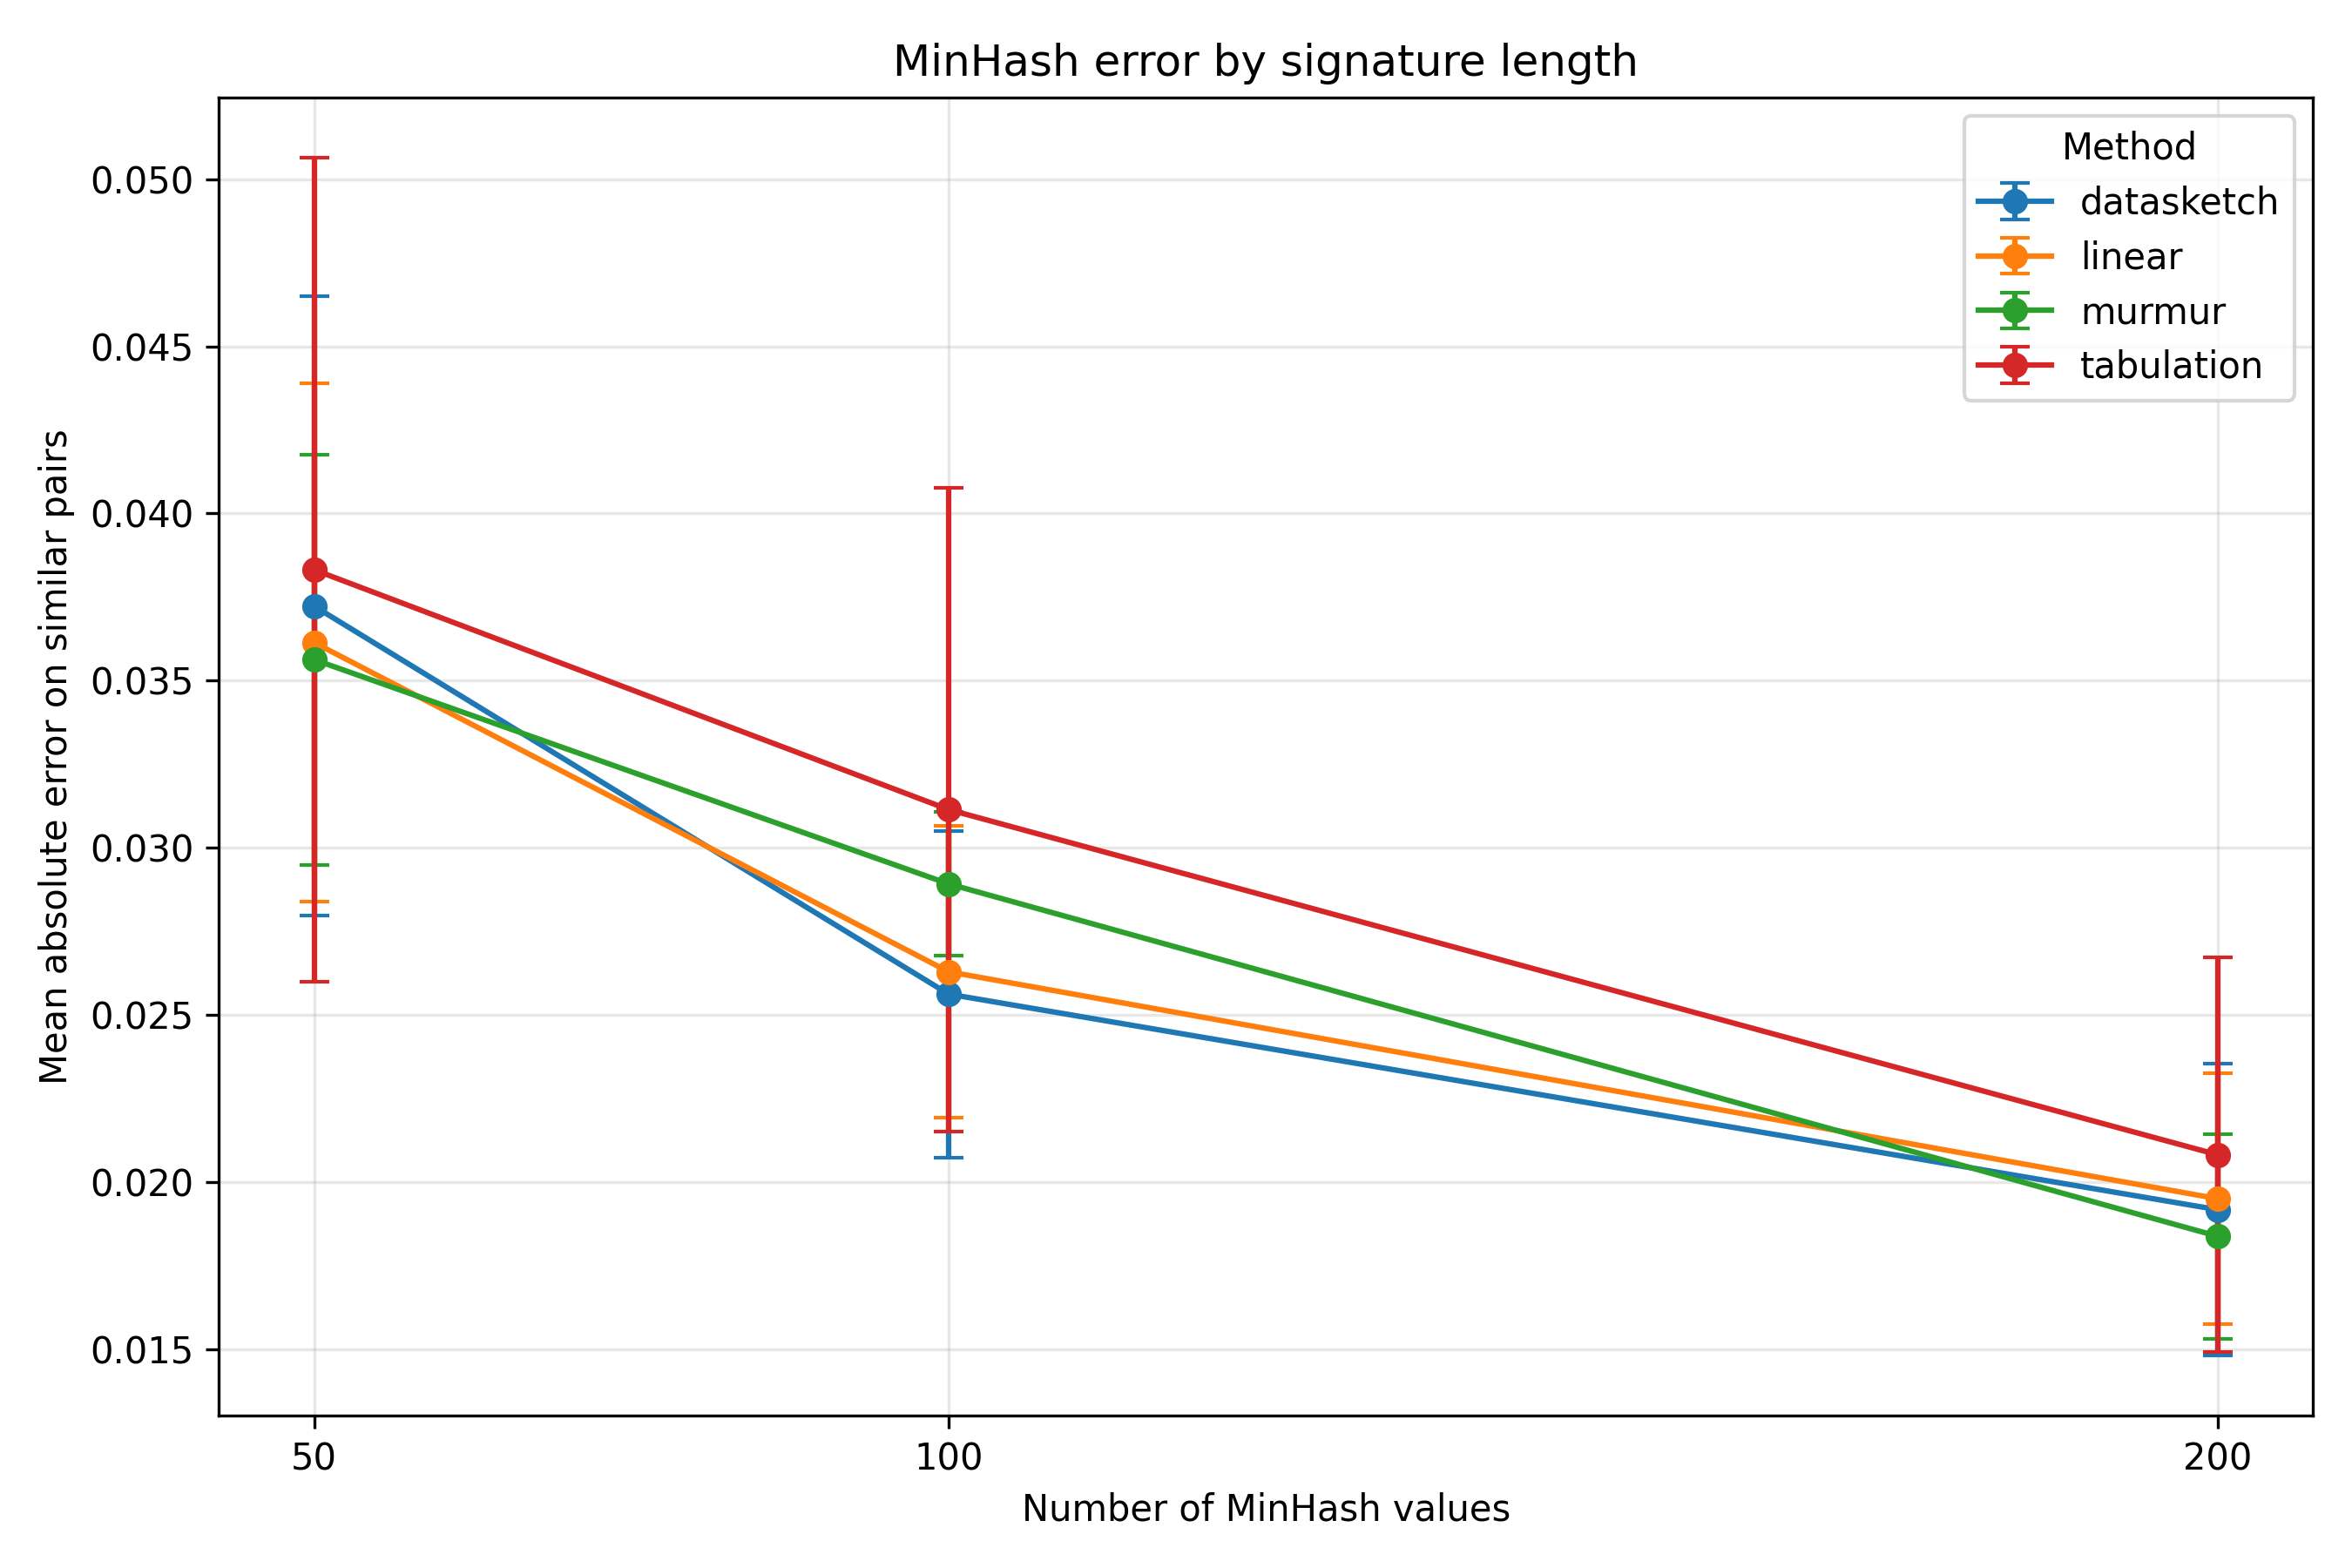

In [30]:
display(Image(filename=str(FIGURES / "validation" / "minhash_validation_error.png"),width=600))

For the 22 similar pairs, estimation error decreases as the number of hash values increases. At 200 hashes, all four methods have a mean absolute error close to 0.02. The custom methods therefore perform similarly to datasketch on this sample. However, because there are only 22 similar pairs, the small differences between the methods should not be treated as a strong ranking.

## Scalability

The Wikipedia experiment measures runtime and candidate reduction up to 10,000 documents.

The important point is that LSH does not compare every possible pair. At 10,000 documents there are almost 50 million possible pairs, but only a small fraction become candidates.

In [15]:
scalability = pd.read_csv(
    TABLES / "wikipedia_scalability.csv"
)

scalability[
    [
        "documents",
        "total_possible_pairs",
        "lsh_candidate_pairs",
        "candidate_reduction",
        "signature_time_seconds",
        "lsh_time_seconds",
        "total_runtime_seconds",
    ]
]

,documents,total_possible_pairs,lsh_candidate_pairs,candidate_reduction,signature_time_seconds,lsh_time_seconds,total_runtime_seconds
0,500,124750,33,0.999735,23.941852,0.055126,24.366534
1,1000,499500,179,0.999642,47.119944,0.125517,48.214874
2,2000,1999000,641,0.999679,100.762081,0.236014,102.912941
3,3000,4498500,1603,0.999644,97.306683,0.285473,99.752110
4,5000,12497500,4411,0.999647,169.402226,0.782633,173.698660
5,7500,28121250,9097,0.999677,264.026130,1.483304,270.706294
6,10000,49995000,13760,0.999725,349.122711,2.494692,359.146025


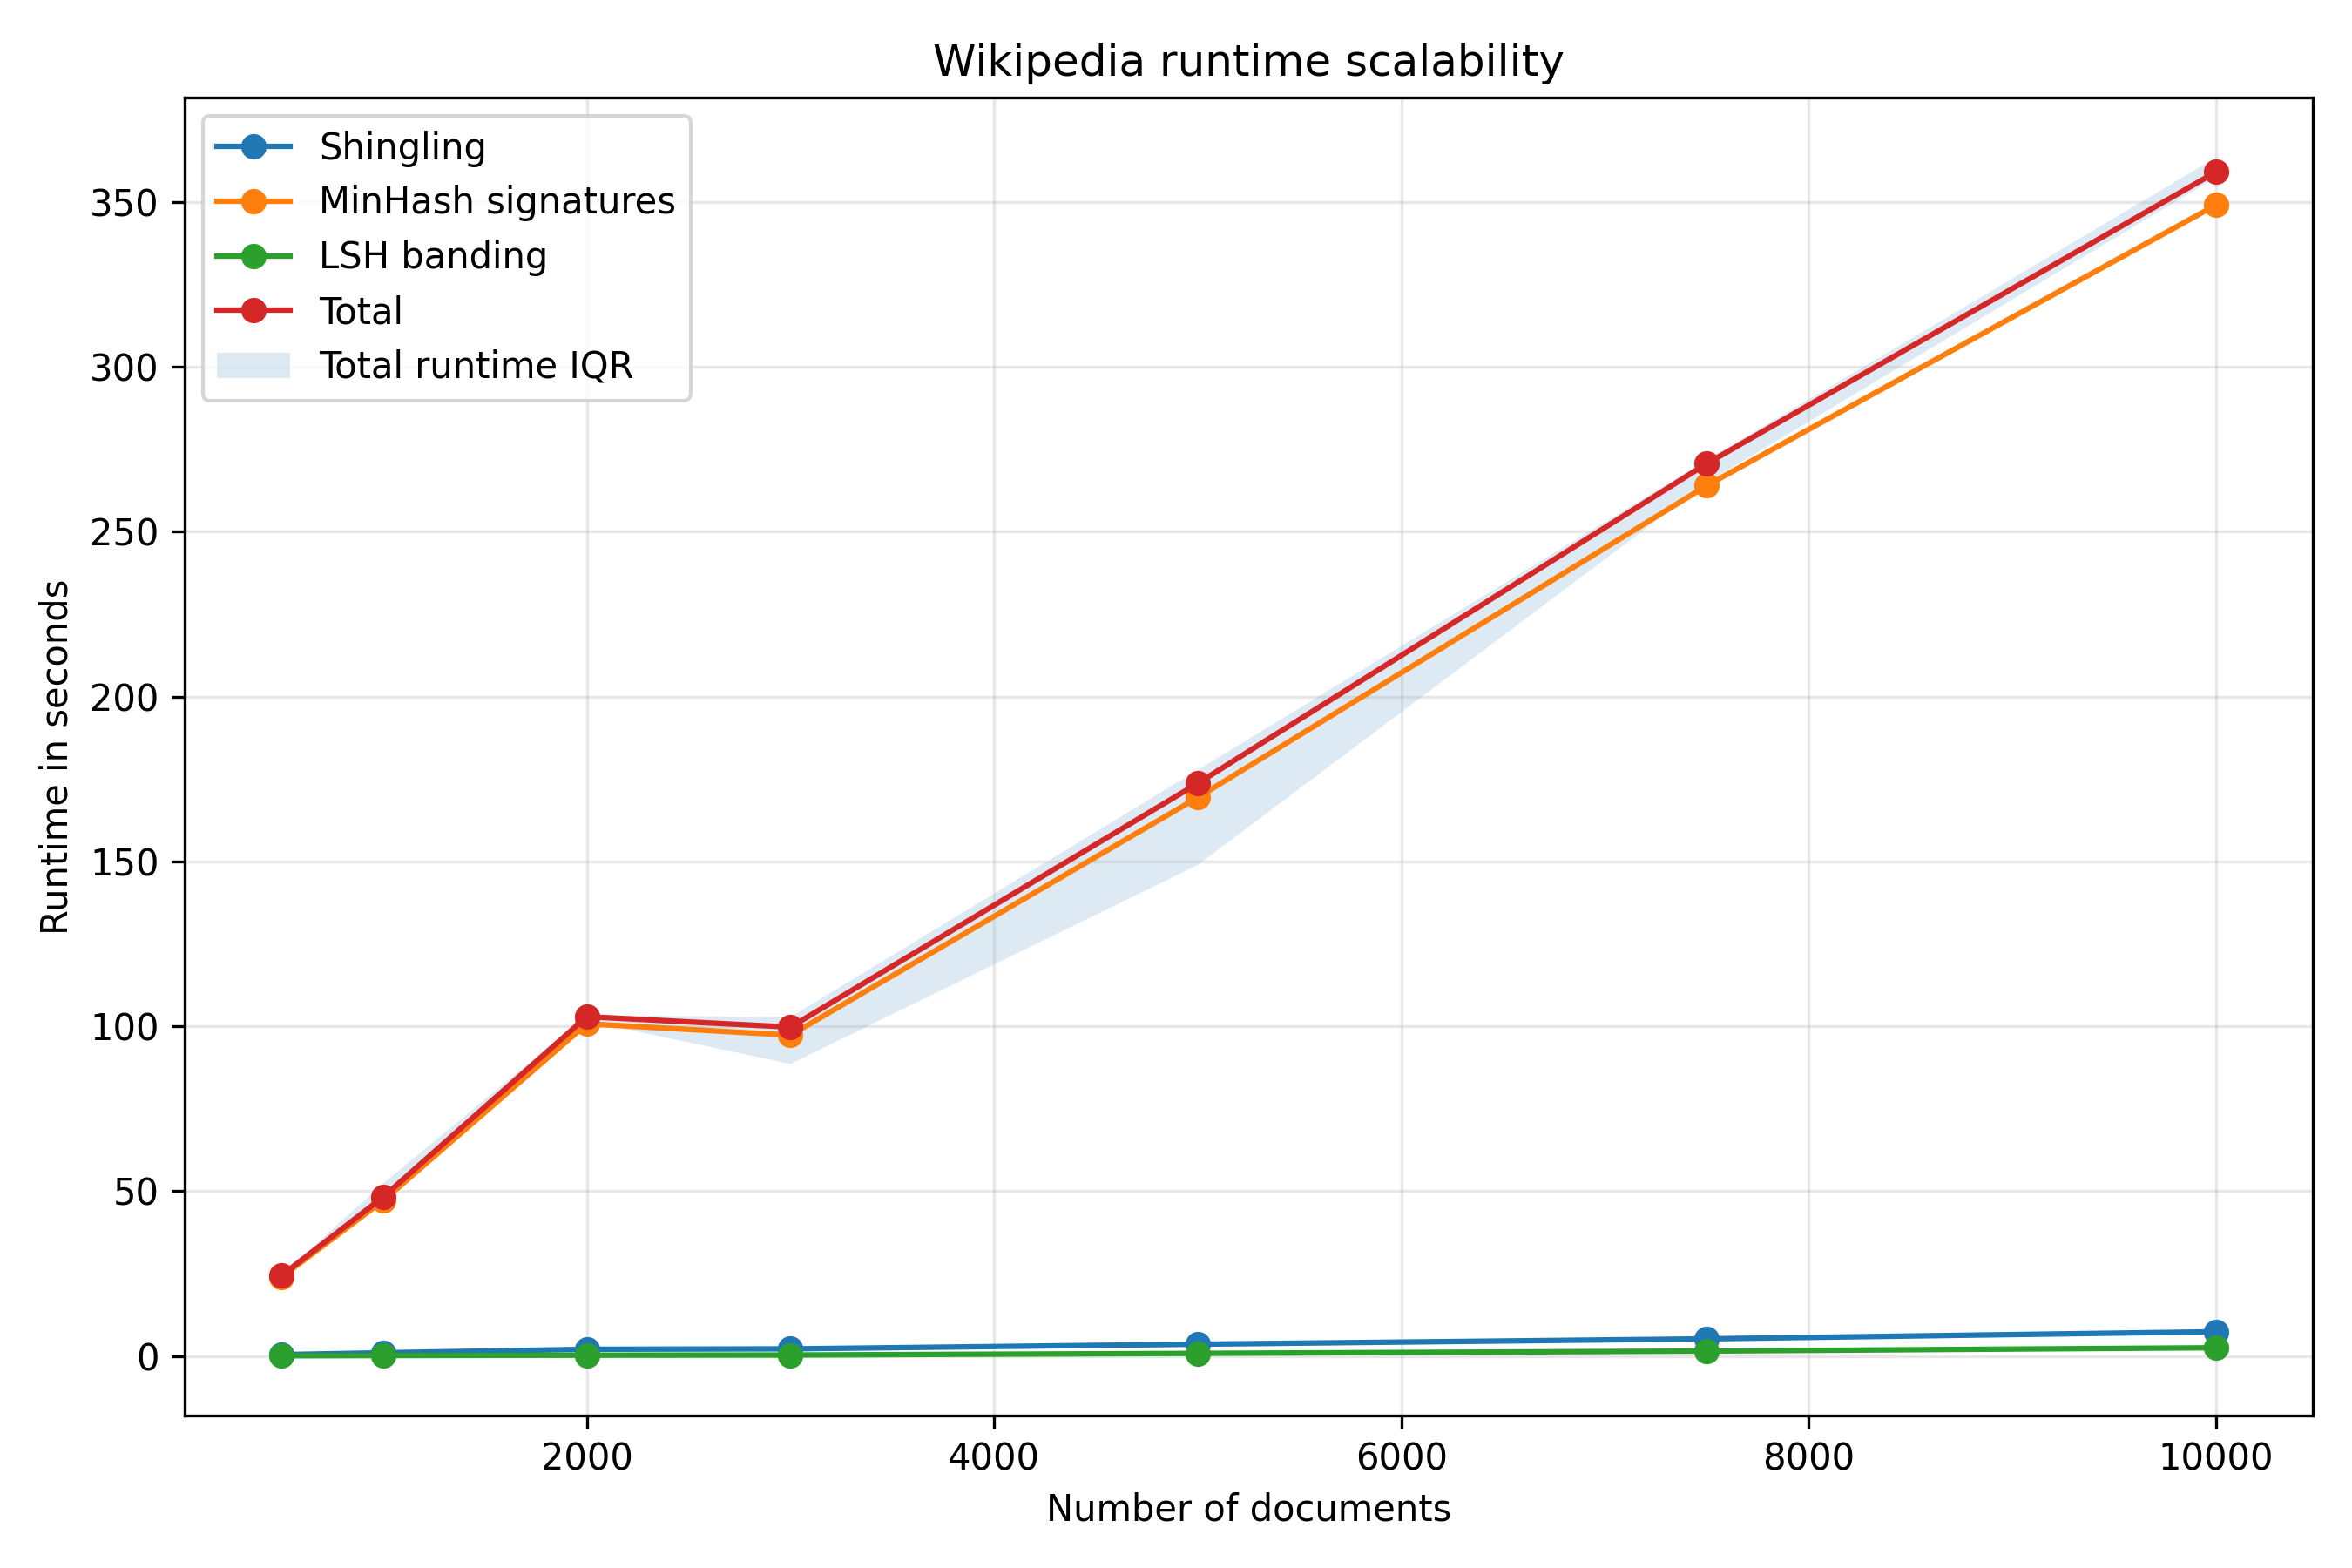

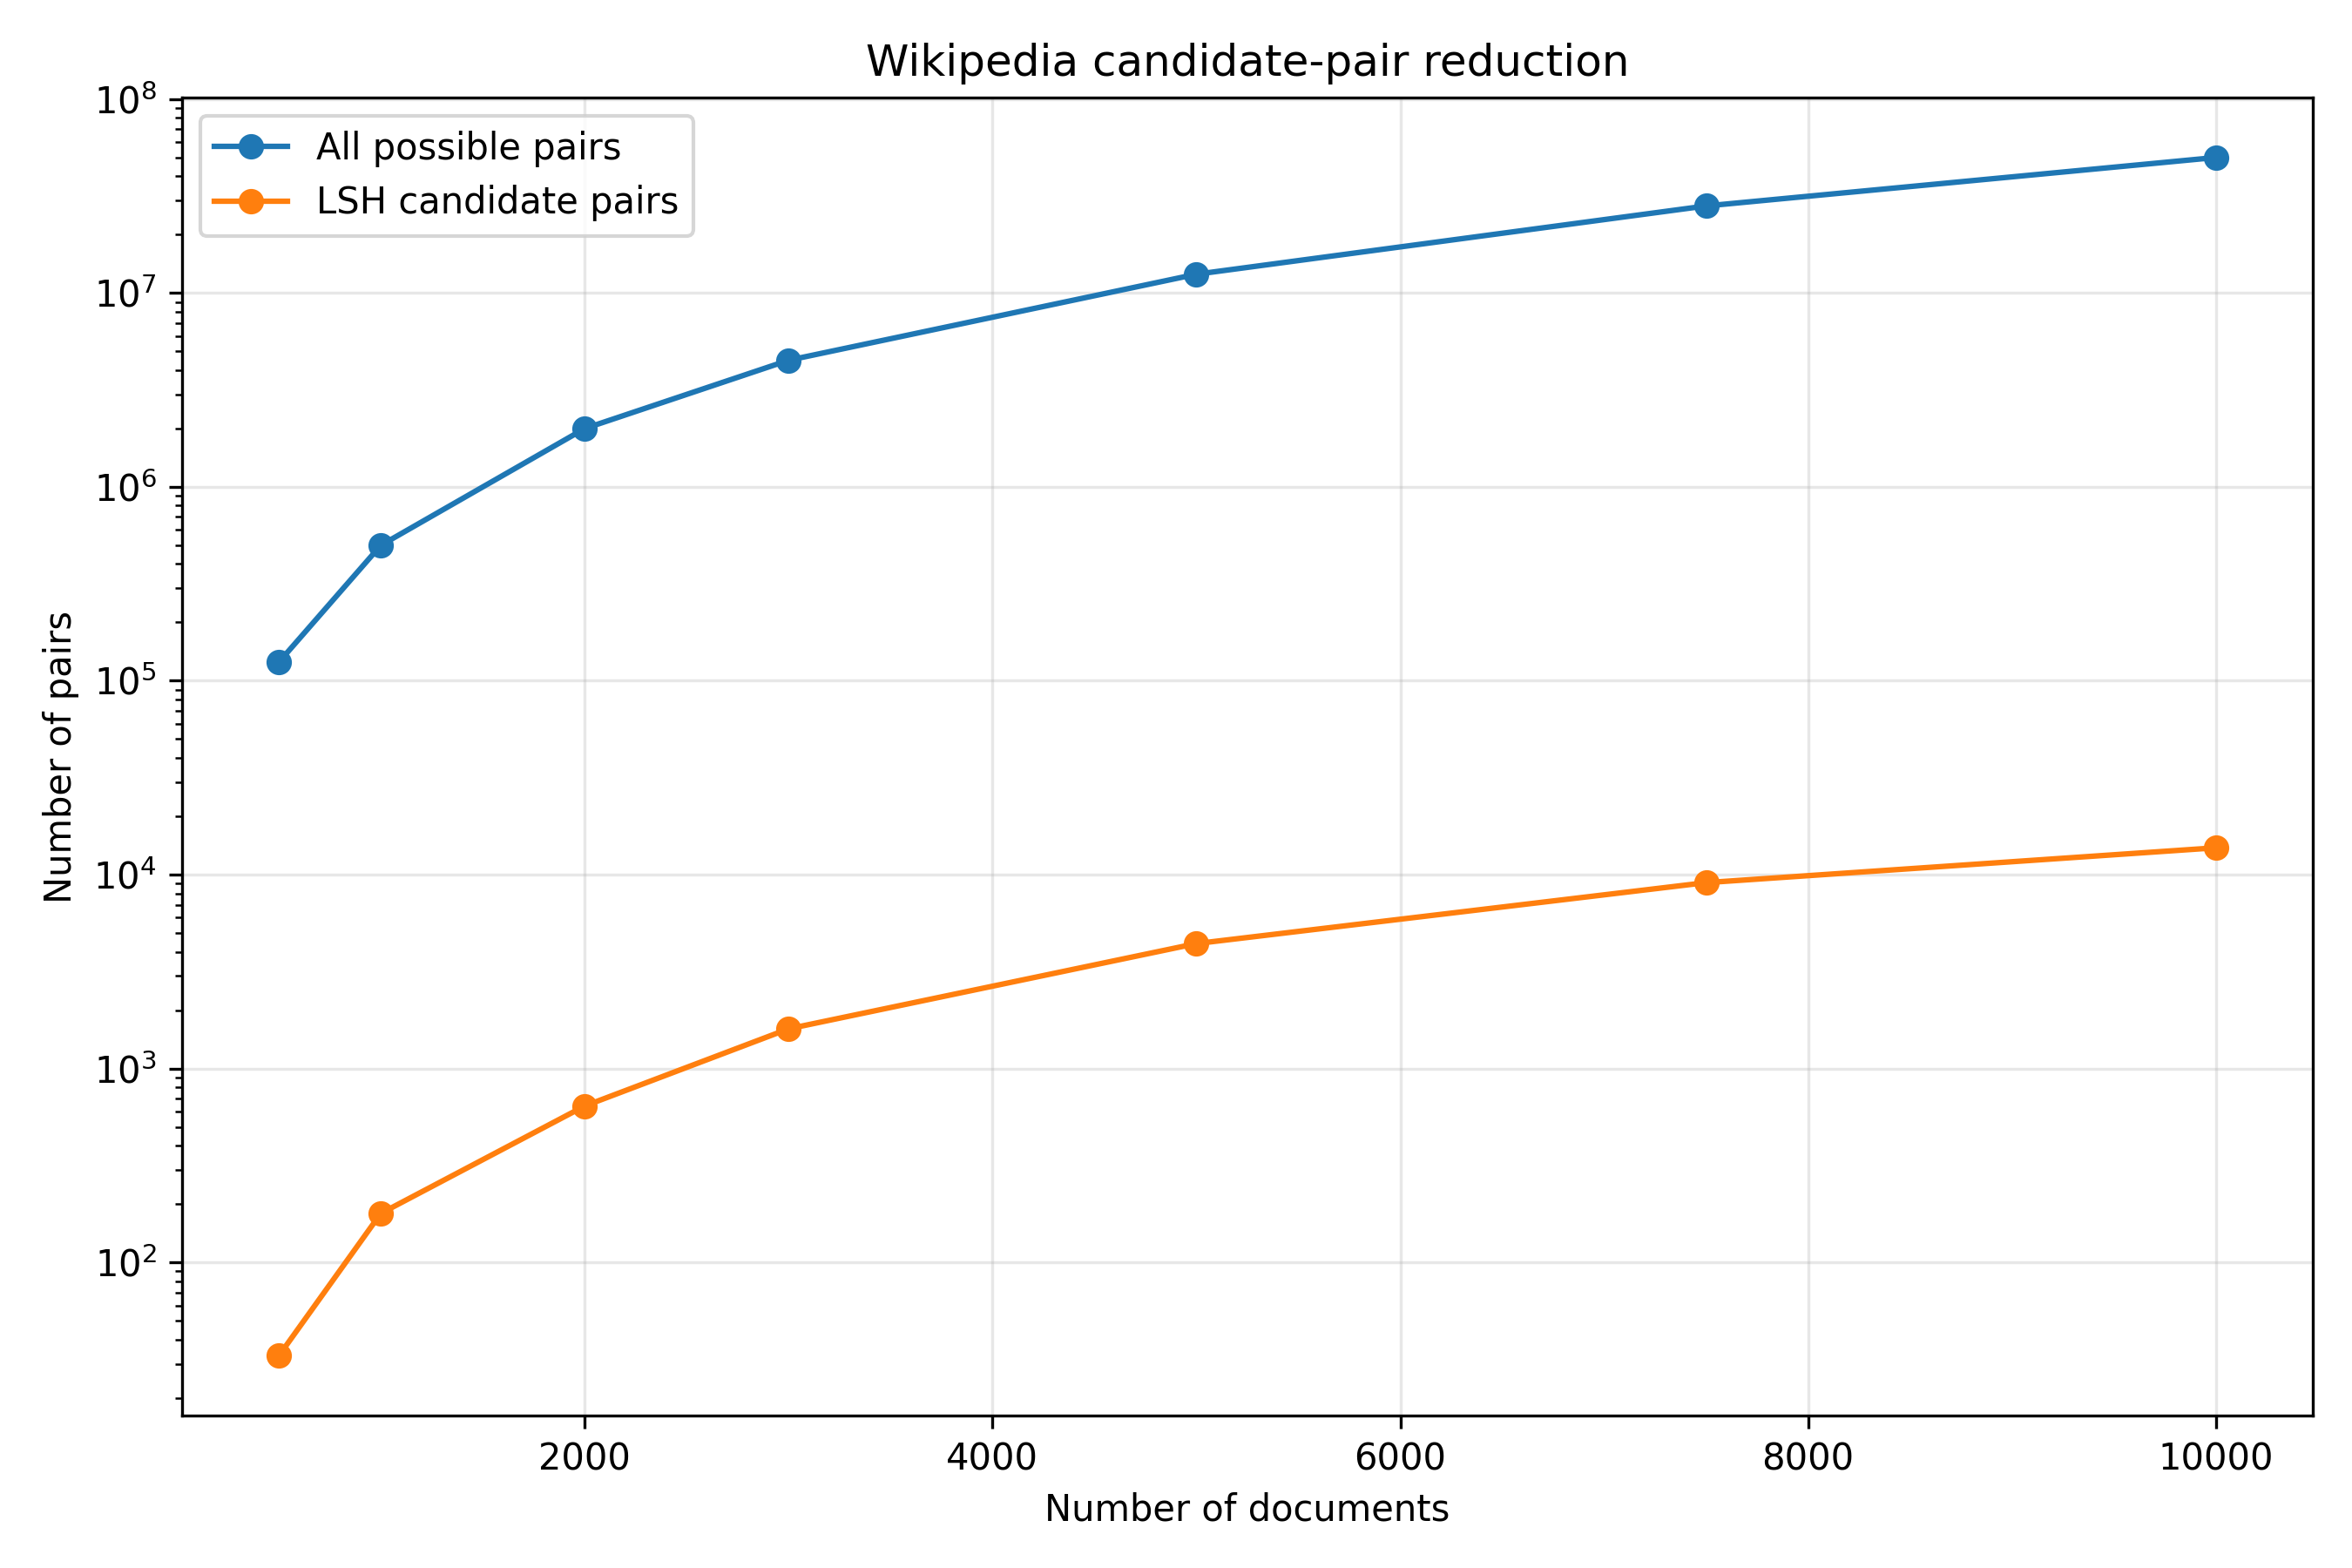

In [31]:
display(Image(filename=str(FIGURES / "scalability" / "wikipedia_runtime_scalability.png"),width=650))
display(Image(filename=str(FIGURES / "scalability" / "wikipedia_candidate_reduction.png"),width=650))

At 10,000 documents, LSH reduces 49,995,000 possible pairs to 13,760 candidates. Signature construction accounts for 349.1 of the 359.1 median runtime seconds, making it the main optimisation target.

## SimHash extension

The optional SimHash experiment compares exact cosine similarity with the value estimated from Hamming distance.

Longer fingerprints usually give a more stable estimate.

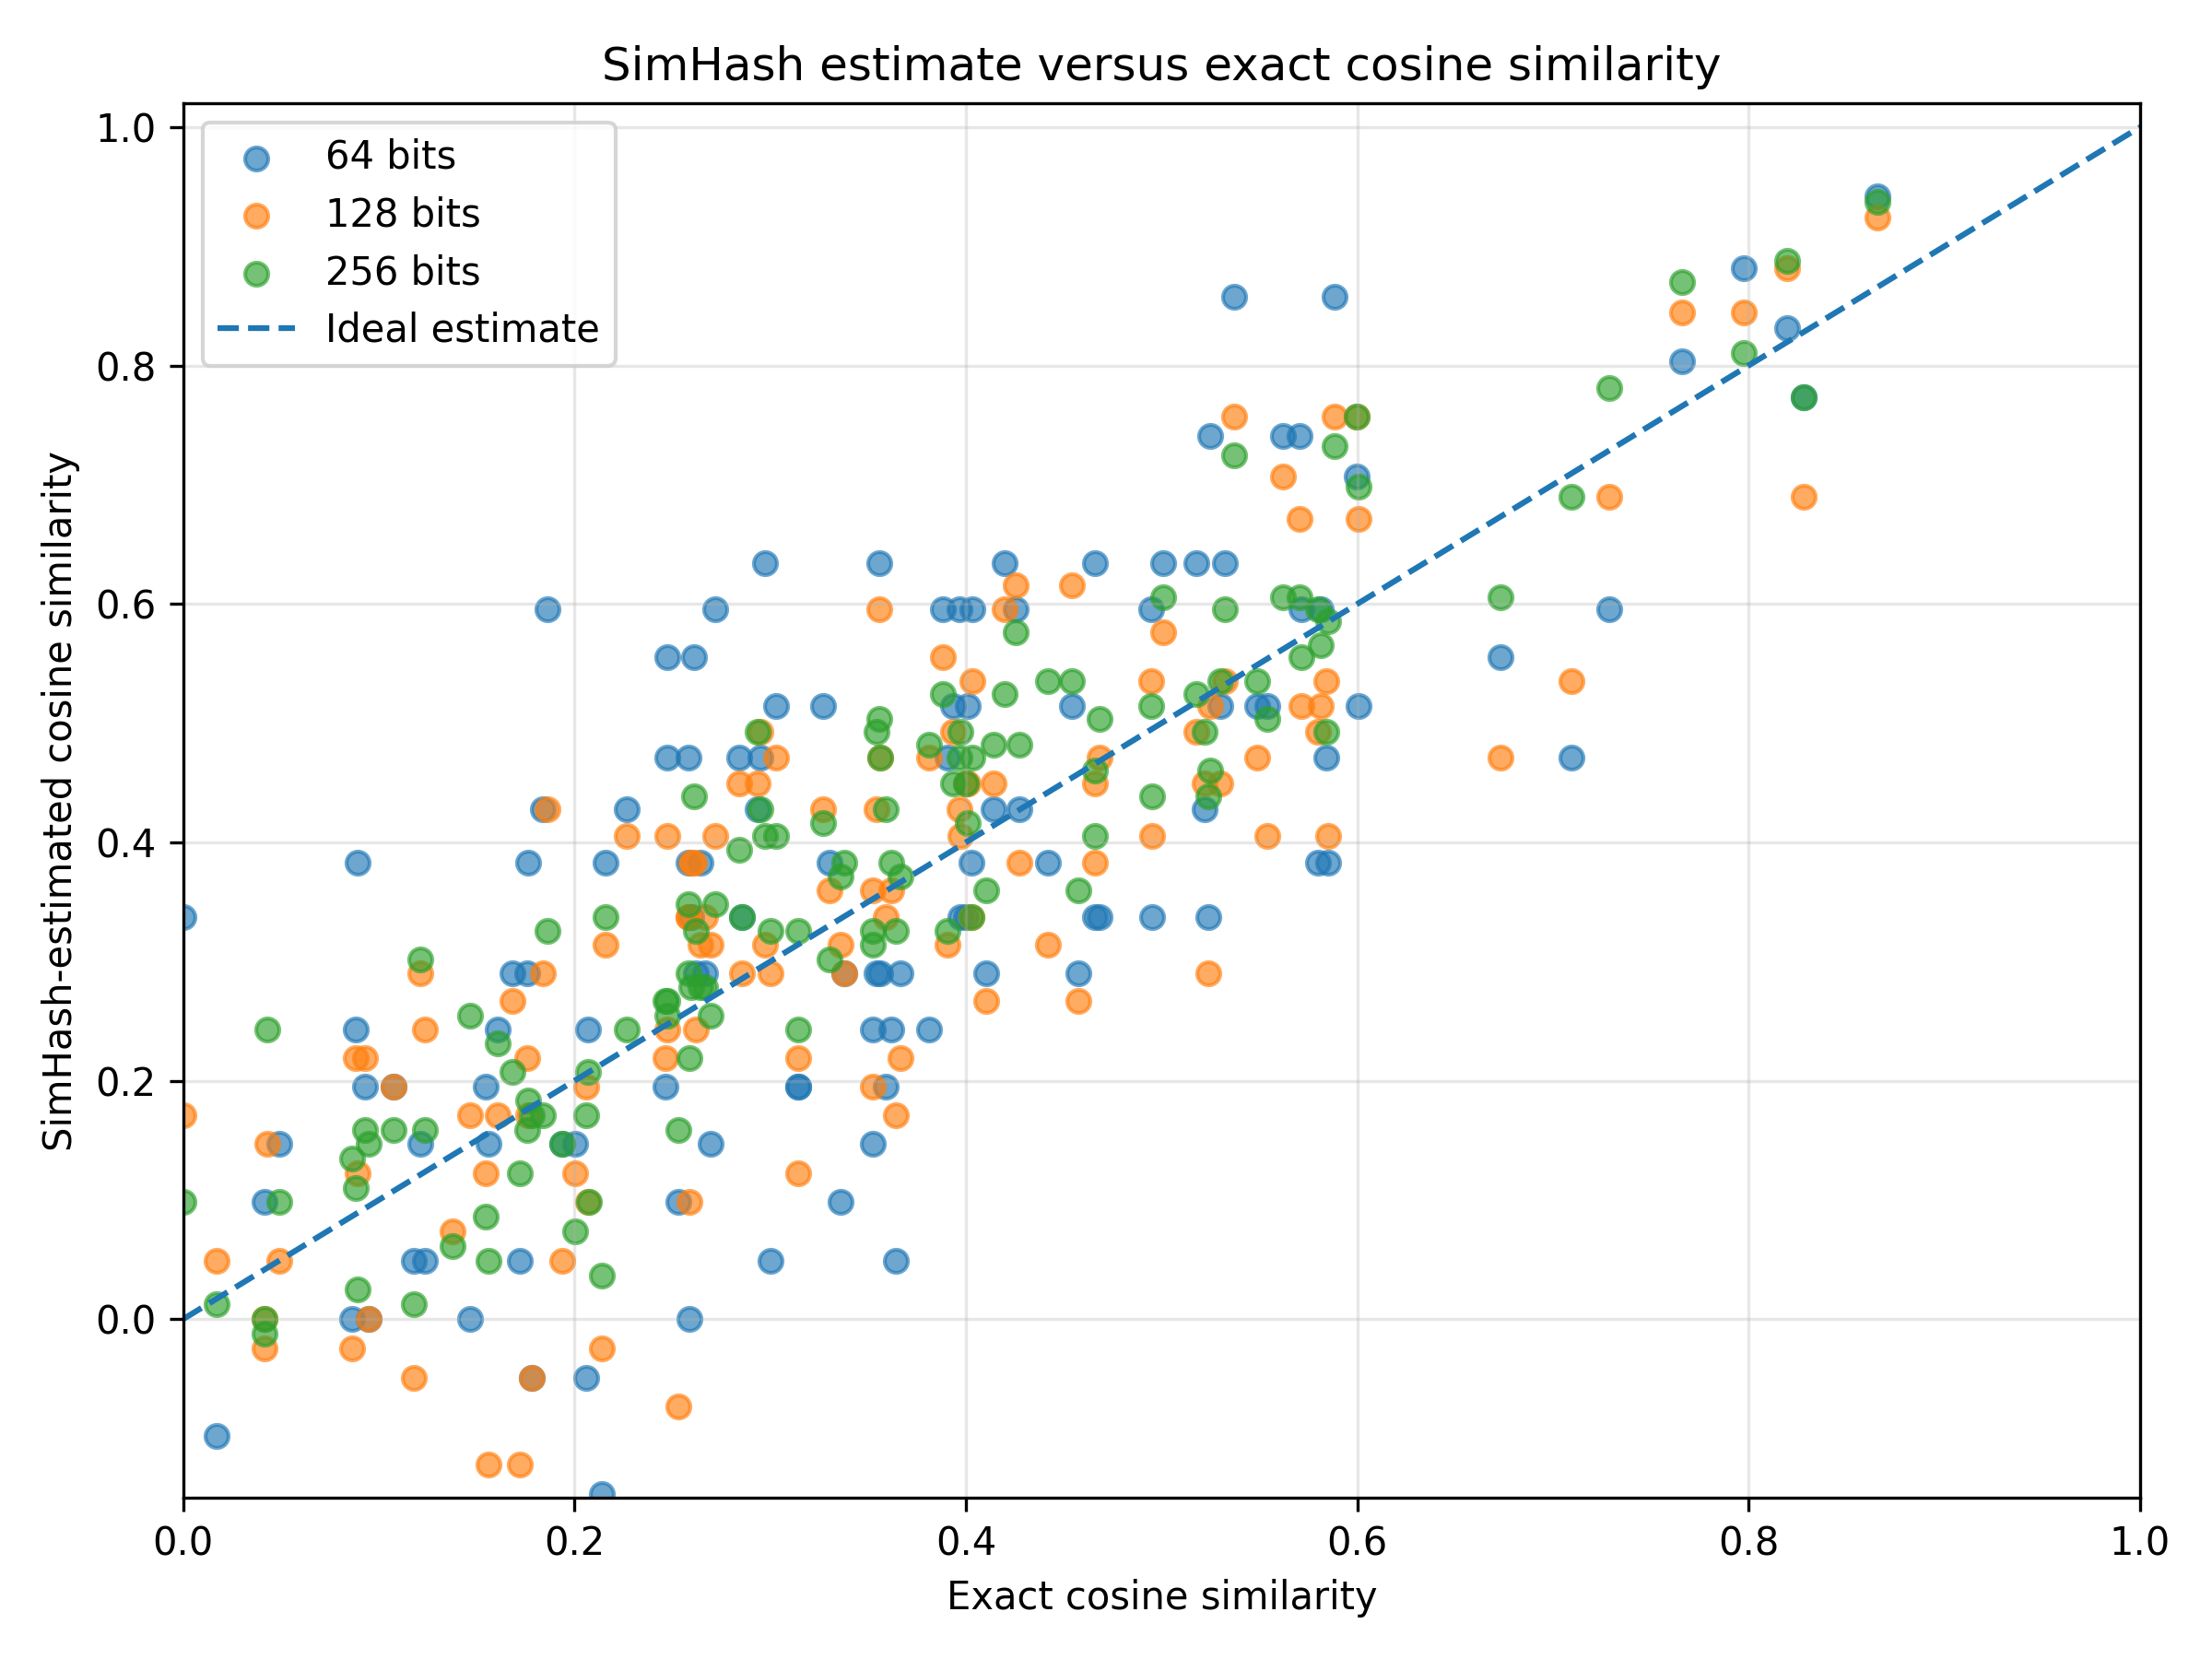

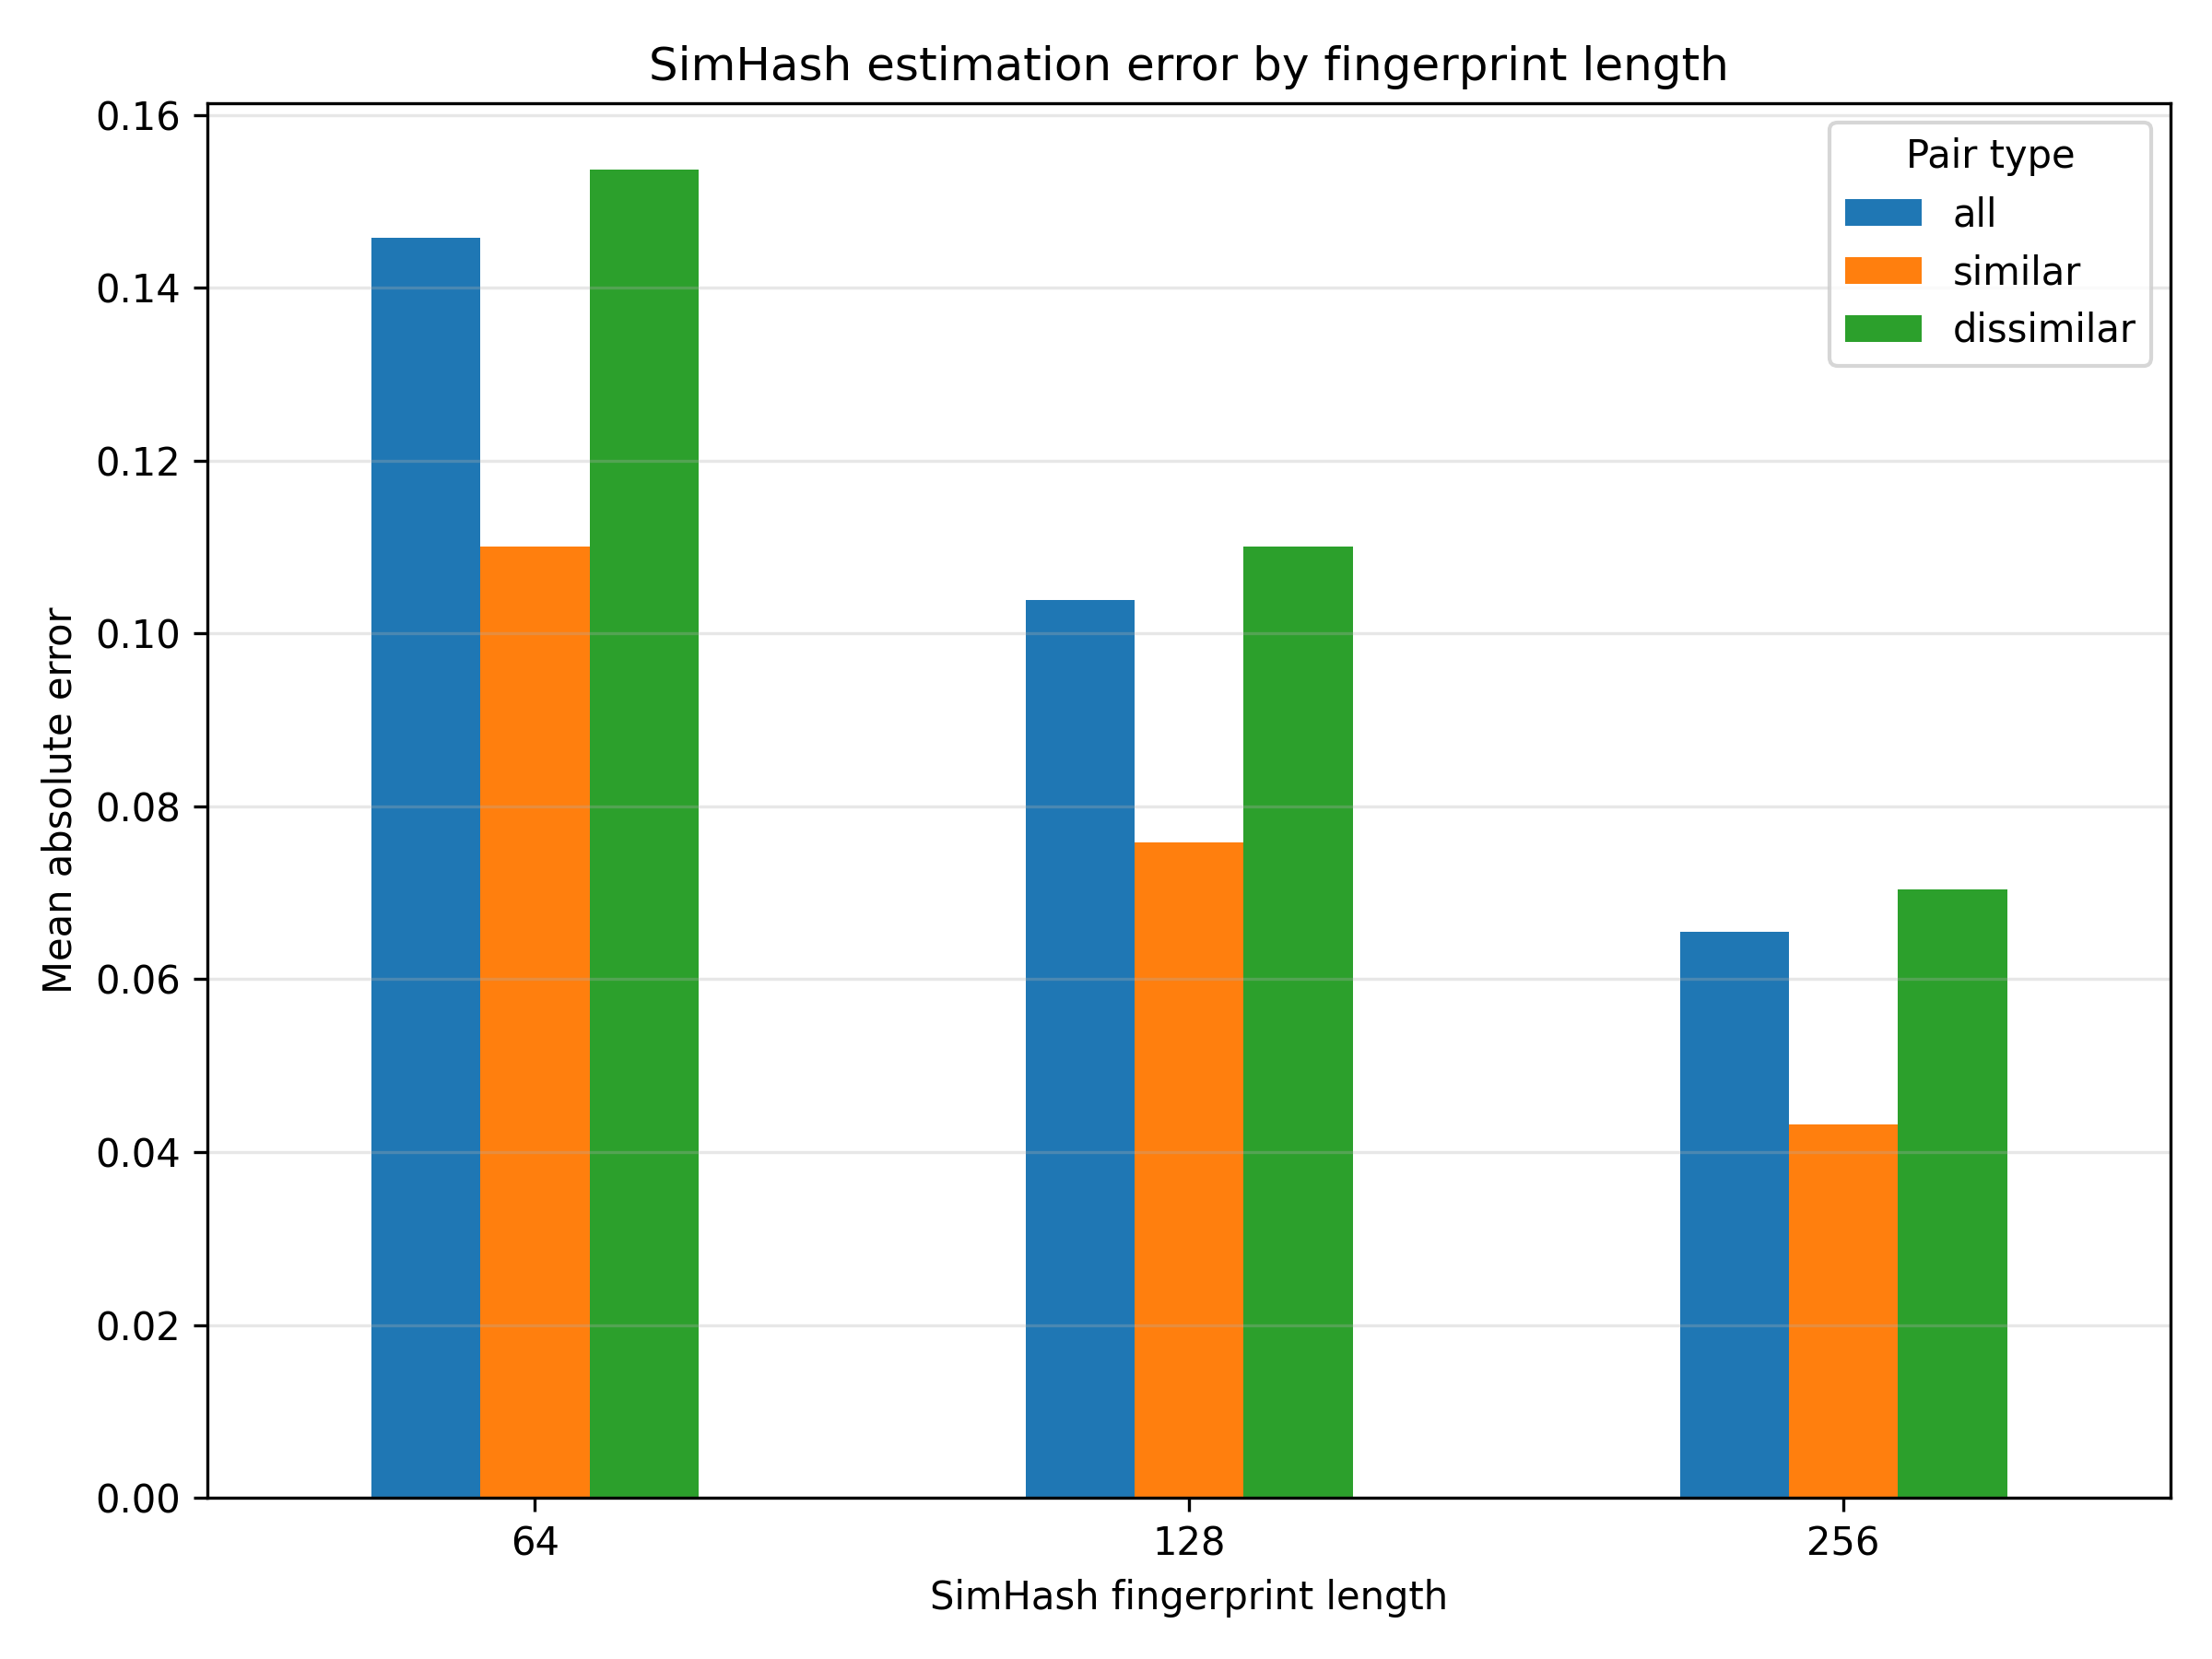

In [32]:
display(Image(filename=str(FIGURES / "extensions" / "simhash_vs_cosine.png"),width=600))
display(Image(filename=str(FIGURES / "extensions" / "simhash_error_by_bits.png"),width=600))

Increasing the fingerprint length improves the SimHash approximation. Across all 122 pairs, mean absolute error decreases from 0.146 at 64 bits to 0.065 at 256 bits, while correlation rises from 0.730 to 0.929. The aggregate values are influenced by the pair composition because 100 of the 122 examples belong to the dissimilar subset.

## Interpretation limits


The reported results depend on a Jaccard threshold of 0.20, one fixed document sample and one fixed hash seed. The best configuration is selected and reported on the same sample. The Wikipedia experiment measures runtime and candidate reduction but does not have a large-scale quality ground truth. The implementation is also single-process and in-memory and the timing values are specific to the machine on which the experiments were executed.

## Final Observations

1. **How many true near-duplicate pairs does LSH find?**  
   The best 20 Newsgroups configuration finds 147 of 156 positive pairs. The best Reuters-21578 configuration finds 142 of 186 positive pairs.

2. **How do the parameters affect the results?**  
   More permissive banding generally increases recall but reduces precision. The preferred shingle size and signature length differ between the datasets.

3. **How many pair comparisons are avoided?**  
   The best main configurations reduce more than 12 million possible pairs to only a few hundred candidates. On Wikipedia, LSH reduces 49,995,000 possible pairs to 13,760 candidates.

The validation experiments also show that the implementation behaves as expected. The controlled LSH results closely follow the theoretical S-curves, and the custom MinHash methods perform similarly to datasketch.